# Table of Contents

- [Abstract](#abstract)
- [Loading Libraries](#loading-libraries)
- [Load Dataset & Summary Statistics](#load-dataset--summary-statistics)
  - [Initial Data Exploration](#initial-data-exploration)
  - [Dataset Information](#dataset-information)
    - [Dataset Overview](#dataset-overview)
    - [Column Types](#column-types)
    - [Missing Values](#missing-values)
- [Data Cleaning and Feature Engineering](#data-cleaning-and-feature-engineering)
  - [Datetime Cleaning and Trip Duration Imputation](#datetime-cleaning-and-trip-duration-imputation)
  - [VendorID Cleaning and Imputation](#vendorid-cleaning-and-imputation)
  - [Passenger Count Cleaning and Imputation](#passenger-count-cleaning-and-imputation)
  - [RatecodeID Null Imputation](#ratecodeid-null-imputation)
  - [Store and Forward Flag Cleaning](#store-and-forward-flag-cleaning)
  - [Congestion Surcharge Initialization](#congestion-surcharge-initialization)
  - [Airport Fee Assignment and Correction](#airport-fee-assignment-and-correction)
  - [Improvement Surcharge Assignment](#improvement-surcharge-assignment)
  - [MTA Tax Assignment](#mta-tax-assignment)
  - [Trip Distance Anomaly Detection and Imputation](#trip-distance-anomaly-detection-and-imputation)
  - [Payment Type and Tip Amount Correction](#payment-type-and-tip-amount-correction)
  - [Sign Consistency Enforcement for Fare Components](#sign-consistency-enforcement-for-fare-components)
  - [Amount Columns Anomaly Imputation](#amount-columns-anomaly-imputation)
  - [JFK Flat Rate Amount Adjustment](#jfk-flat-rate-amount-adjustment)
  - [Adjusted Total Amount Calculation](#adjusted-total-amount-calculation)
- [Visualization](#visualization)
  - [Top 20 Most Frequent Pickup → Dropoff Trips](#top-20-most-frequent-pickup--dropoff-trips)
  - [Payment Type Distribution](#payment-type-distribution)
  - [Average Fare Amount by Payment Type](#average-fare-amount-by-payment-type)
  - [Average Total Amount by Vendor](#average-total-amount-by-vendor)
  - [Trips per Time Bucket by Vendor](#trips-per-time-bucket-by-vendor)
  - [Average Fare, Tip, and Total Amounts by Time Bucket](#average-fare-tip-and-total-amounts-by-time-bucket)
  - [Geo-spatial Pickup and Drop-off Hotspots](#geo-spatial-pickup-and-drop-off-hotspots)
- [Final Cleaned Dataset Subset](#final-cleaned-dataset-subset)
- [Building a Predictive Model for Fare Amount](#building-a-predictive-model-for-fare-amount)
  - [Select Features and Target](#select-features-and-target)
  - [Sampling Subset](#sampling-subset)
  - [Splitting Data](#splitting-data)
  - [Preprocessing](#preprocessing)
  - [Hyper-parameter Tuning](#hyper-parameter-tuning)
  - [Final Model Training and Validation](#final-model-training-and-validation)
  - [Final Model Evaluation on Test Set](#final-model-evaluation-on-test-set)
- [Conclusion](#conclusion)


# Abstract

This analysis examined the Q1 2019 New York City Yellow Taxi dataset, comprising over 305,000 records, which faced common data quality hurdles like missing values, outliers, and inconsistencies in time stamps, locations, and payment details.  
- We built a step-by-step preprocessing pipeline to tackle these: fixing time errors by swapping mismatched pickup and dropoff dates for negative trip lengths, filling outliers with smart averages based on similar trips (e.g., by zone IDs and time-of-day groups), and matching fees to Taxi and Limousine Commission (TLC) rules (e.g., $52 flat JFK fares, no congestion charges before 2019).  
- Exploratory charts revealed standout trends, like heavy back-and-forth traffic in Midtown (e.g., zones 237↔236), 71% of rides paid by credit card, and higher fares during late-night hours.  
- For forecasting fares, we tested three regression models—Random Forest, XGBoost, and Support Vector Regression—through scikit-learn pipelines with scaling for numbers and encoding for categories. We tuned settings using RandomizedSearchCV (2-fold cross-validation on a sampled training set), where XGBoost shone on the test data (R² = 0.91, MAE = $0.89, RMSE = $3.13).  

Overall, the results highlight how gradient boosting handles fare predictions well in trip data like this, keeping errors under 7% of the average $13 fare. This setup has real-world perks for boosting taxi revenue and city traffic insights, opening doors to add map-based features or track changes over time.

# Loading Libraries
We import libraries for **data handling, visualization, statistics, and modeling**:

* **pandas** and **numpy** handle data frames and numerical operations.
* **matplotlib**, **seaborn**, and **plotly.express** create static and interactive plots.
* **scipy.stats.mode** computes the most frequent value; **matplotlib.ticker** customizes axis ticks.

For **machine learning**:

* **sklearn** tools handle train/test splits, preprocessing (`OneHotEncoder`, `StandardScaler`), pipelines, models (`RandomForestRegressor`, `SVR`), and evaluation metrics (`MAE`, `MSE`, `R²`).
* **xgboost** provides efficient gradient boosting models.

Finally, **warnings.filterwarnings('ignore')** hides non-critical warnings for cleaner output.

In [5]:
# ---------------------------Data Science Libraries------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode
import matplotlib.ticker as mticker
import plotly.express as px
import folium
import geopandas as gpd
from folium.features import GeoJsonTooltip
from IPython.display import display, HTML
import os
# ---------------------------Modeling Libraries-----------------------------------
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


# Load Dataset & Summary Statistics

We load the NYC Yellow Taxi dataset from CSV and generate descriptive statistics for all numeric columns.  
Using `.transpose()` flips the output for easier readability (each row = one feature).


In [6]:
df = pd.read_csv(r"D:\LYNX\Dataset\Yellow_Taxi_Assignment.csv")
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
VendorID,304978.0,1.672786,0.514069,1.00,1.0,2.00,2.00,6.00
passenger_count,295465.0,1.479126,1.108255,0.00,1.0,1.00,2.00,6.00
trip_distance,304978.0,4.587589,434.226624,-16.86,1.0,1.73,3.21,177247.40
RatecodeID,295465.0,1.142931,2.969941,1.00,1.0,1.00,1.00,99.00
PULocationID,304978.0,163.744975,66.570490,1.00,121.0,162.00,234.00,265.00
DOLocationID,304978.0,160.988898,70.975905,1.00,107.0,162.00,234.00,265.00
payment_type,304978.0,1.240463,0.528257,0.00,1.0,1.00,2.00,5.00
fare_amount,304978.0,13.510189,12.636651,-197.00,6.5,9.50,15.00,455.00
extra,304978.0,0.903506,1.185321,-6.00,0.0,0.50,1.00,18.50
mta_tax,304978.0,0.492755,0.074023,-0.50,0.5,0.50,0.50,2.54


# Initial Data Exploration

The descriptive statistics reveal several issues in the dataset:

- **Trip Distance**: Extreme outliers (negative values and max ≈ 177k miles).  
- **Amount Columns**: Negative values and some anomalies observed (total_amount ≈ 561$).
- **Congestion_surcharge**: Based on Data Dictionary, its not applicable for 2018 Q1. 
- **Passenger Count**: Includes 0 passengers (possible error).  

## Dataset Information

The `.info()` method provides a concise summary of the dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304978 entries, 0 to 304977
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               304978 non-null  int64  
 1   tpep_pickup_datetime   304978 non-null  object 
 2   tpep_dropoff_datetime  304978 non-null  object 
 3   passenger_count        295465 non-null  float64
 4   trip_distance          304978 non-null  float64
 5   RatecodeID             295465 non-null  float64
 6   store_and_fwd_flag     295465 non-null  object 
 7   PULocationID           304978 non-null  int64  
 8   DOLocationID           304978 non-null  int64  
 9   payment_type           304978 non-null  int64  
 10  fare_amount            304978 non-null  float64
 11  extra                  304978 non-null  float64
 12  mta_tax                304978 non-null  float64
 13  tip_amount             304978 non-null  float64
 14  tolls_amount           304978 non-nu

### Dataset Overview
- **Rows:** 304,978  
- **Columns:** 19  
### Column Types
- **pickup/dropoff datetime:** must be change to datetime. 
- **store_and_fwd_flag:** must be chabge to Boolean.   
### Missing Values
- **passenger_count**: ~9.5k missing  
- **RatecodeID**: ~9.5k missing  
- **store_and_fwd_flag**: ~9.5k missing  
- **congestion_surcharge**: ~72k missing  
- **airport_fee**: ~199k missing  

# Data Cleaning and Features Engineering

## Datetime and Trip Duration

### Problem:
- The taxi trip data shows inconsistent `tpep_pickup_datetime` and `tpep_dropoff_datetime` entries, resulting in 169 negative `trip_duration` values down to -44 minutes where pickups exceed dropoffs. 
- Outliers extend to 1440 minutes, pulling the mean to 16.7 minutes and std to 59.9 across 304,978 trips, which hinders accurate analysis. 
- Original datetimes require preservation to track modifications.
### Solution Strategy:
- Archive originals first, then convert to datetime format and swap pickup-dropoff pairs for negatives to ensure positive durations. 
- Bucket pickup hours into `time_bucket` categories like morning or evening for grouping context. 
- Identify outliers above the 99th percentile (61 minutes) and impute them with means from similar trips by `PULocationID`, `DOLocationID`, and `time_bucket`, using the global mean as fallback.
### Results:
- Datetimes convert, and initial `trip_duration` exposes 169 negatives with min -44 minutes and max 1440. 
- Swapping corrects them, lifting min to 0 and mean slightly to 16.7 while keeping max unchanged. 
- Hours extract to form `time_bucket` (e.g., 'morning' for 5-10 AM), dropping the temp column. 
- Out of 3050 extremes (61-1440 minutes), imputation via grouped means caps max at 61.1, drops mean to 13.7, std to 10.2, and adjusts 75th percentile to 17.7.

In [8]:
# --- Preserve original columns for reference and comparison
if 'tpep_pickup_datetime_orig' not in df.columns:
    df['tpep_pickup_datetime_orig'] = df['tpep_pickup_datetime'].copy()
if 'tpep_dropoff_datetime_orig' not in df.columns:
    df['tpep_dropoff_datetime_orig'] = df['tpep_dropoff_datetime'].copy()

# Fix datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])


# Calculate initial duration (minutes)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print("\n", f"Trip duration before checking for negative duration:", df['trip_duration'].describe())

# Check if tpep_pickup_datetime > tpep_dropoff_datetime (i.e., duration < 0), then swap those two values on that row
neg_mask = df['trip_duration'] < 0
print(f"Found {neg_mask.sum()} trips with negative duration")

# Swap PU and DO times for those rows
df.loc[neg_mask, ['tpep_pickup_datetime', 'tpep_dropoff_datetime']] = (
    df.loc[neg_mask, ['tpep_dropoff_datetime', 'tpep_pickup_datetime']].values
)

# Recalculate duration after swap
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print("\n", f"Trip duration after swapping incorrect datetime:", df['trip_duration'].describe())

# Create time bucket based on edited tpep_pickup_datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
def time_bucket(hour):
    if 5 <= hour < 10: return 'morning'
    elif 10 <= hour < 16: return 'midday'
    elif 16 <= hour < 19: return 'evening_rush'
    elif 19 <= hour < 24: return 'evening'
    else: return 'night'
df['time_bucket'] = df['pickup_hour'].apply(time_bucket)

initial_similar_groups = ['PULocationID', 'DOLocationID', 'time_bucket']

# Check trip duration anomalies and impute based on mean (since continuous) of similar trips; fallback to global mean
# Compute direct dur_99 for extreme detection
dur_99 = df['trip_duration'].quantile(0.99)
print(f"99th percentile duration: {dur_99}")

# Detect extremes (> dur_99)
extreme_mask = df['trip_duration'] > dur_99
print(f"Extreme durations (> {dur_99} min): {extreme_mask.sum()} rows")
if extreme_mask.sum() > 0:
    print(f"Range of extremes: {df.loc[extreme_mask, 'trip_duration'].min():.0f} to {df.loc[extreme_mask, 'trip_duration'].max():.0f} min")

# Clean subset for means (non-extreme)
clean_mask = df['trip_duration'] <= dur_99
df_clean = df.loc[clean_mask].copy()

# Grouped mean duration by similar trips
mean_dur_similar = df_clean.groupby(initial_similar_groups)['trip_duration'].mean()
global_mean_dur = df_clean['trip_duration'].mean()

# Impute extremes
df['imputed_dur'] = df[initial_similar_groups].apply(
    lambda x: mean_dur_similar.get((x['time_bucket'], x['PULocationID'], x['DOLocationID']), global_mean_dur), 
    axis=1
)
df.loc[extreme_mask, 'trip_duration'] = df.loc[extreme_mask, 'imputed_dur']
df.drop(columns=['imputed_dur'], inplace=True, errors='ignore')

print(f"Trip duration after extreme fix:", df['trip_duration'].describe())
if extreme_mask.sum() > 0:
    print(f"Extremes fixed: {extreme_mask.sum()} rows imputed (now max: {df['trip_duration'].max():.1f} min)")


 Trip duration before checking for negative duration: count    304978.000000
mean         16.697175
std          59.903429
min         -44.133333
25%           6.600000
50%          11.016667
75%          18.050000
max        1439.866667
Name: trip_duration, dtype: float64
Found 169 trips with negative duration

 Trip duration after swapping incorrect datetime: count    304978.000000
mean         16.697930
std          59.903219
min           0.000000
25%           6.600000
50%          11.016667
75%          18.050000
max        1439.866667
Name: trip_duration, dtype: float64
99th percentile duration: 61.10383333333302
Extreme durations (> 61.10383333333302 min): 3050 rows
Range of extremes: 61 to 1440 min
Trip duration after extreme fix: count    304978.000000
mean         13.685010
std          10.158645
min           0.000000
25%           6.600000
50%          11.016667
75%          17.650000
max          61.100000
Name: trip_duration, dtype: float64
Extremes fixed: 3050 rows imp

### Plot Overview:
- The distribution shows a right-skewed shape with most trips clustering between 0 and 20 minutes, peaking near the median of 11 minutes, reflecting typical short urban rides.
- Post-cleaning, no negatives or extremes distort the view, with the mean at 13.7 minutes and 75th percentile at 17.7, indicating effective outlier handling.
- KDE smooths reveal a long tail up to 61 minutes, but density drops sharply beyond 30 minutes, highlighting that over 75% of 304,978 trips are under 18 minutes.

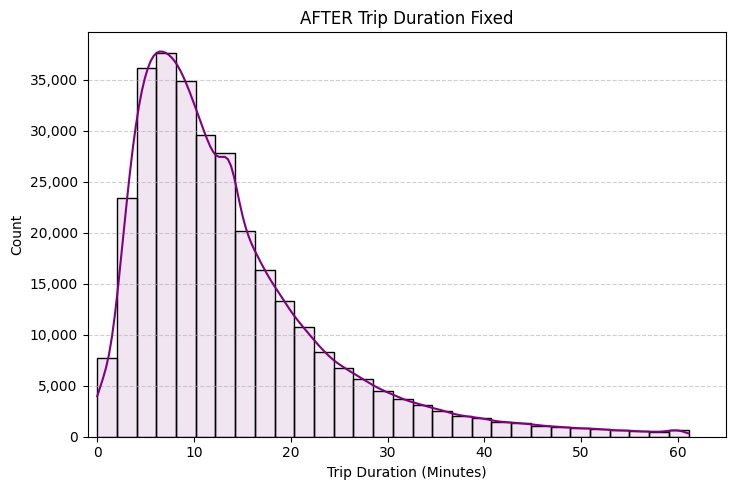

In [9]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
sns.histplot(df['trip_duration'], bins=30, kde=True, color='purple', alpha=0.1)
plt.title('AFTER Trip Duration Fixed', fontsize=12)
plt.xlabel('Trip Duration (Minutes)')
plt.xlim(-1, 65)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## VendorID Cleaning and Imputation

### Problem:
- The dataset contains 503 invalid `VendorID` entries (500 as 4, 3 as 5), outside official valid codes of 1, 2, 6, and 7, which could bias vendor-based analysis.
- Original `VendorID` values must be preserved to maintain data integrity and enable comparisons.

### Solution Strategy:
- Backup originals to `VendorID_orig` if missing, then identify invalids not in [1, 2, 6, 7].
- Compute overall mode as fallback, and group modes from valid `VendorID` only within `PULocationID`, `DOLocationID`, and `time_bucket` subgroups.
- Impute invalids with group mode or overall fallback, cast to int, and drop temporary columns while retaining `time_bucket`.

### Results:
- Imputation shifts invalids primarily to 2 (201,537 total), with 1 at 102,920 and 6 at 521; no 7 appears but all are now valid.
- Post-fix validation confirms 100% compliance with valid codes across the dataset, ensuring clean vendor categorization.

In [10]:
# Preserve original VendorID before any fixes
if 'VendorID_orig' not in df.columns:
    df['VendorID_orig'] = df['VendorID'].copy()

# Valid codes from official Data Dictionary
valid_vendors = [1, 2, 6, 7]

# Detect invalids
invalid_mask = ~df['VendorID'].isin(valid_vendors)
print(f"Invalid VendorID rows: {invalid_mask.sum()}")
print("Invalid value counts:")
print(df.loc[invalid_mask, 'VendorID'].value_counts().sort_index())


# Overall mode as fallback
overall_mode = int(df['VendorID'].mode()[0]) if len(df['VendorID'].mode()) > 0 else 1

# Group mode: Only from VALID VendorIDs in each group
group_mode = df.groupby(initial_similar_groups)['VendorID'].agg(
    lambda x: int(x[x.isin(valid_vendors)].mode()[0]) if len(x[x.isin(valid_vendors)].mode()) > 0 
    else overall_mode
)

# Impute for invalids (fallback to overall if no group match)
df['imputed_vendor'] = df[initial_similar_groups].apply(
    lambda x: group_mode.get((x['PULocationID'], x['DOLocationID'], x['time_bucket']), overall_mode), axis=1
)
df.loc[invalid_mask, 'VendorID'] = df.loc[invalid_mask, 'imputed_vendor'].astype(int)  # Ensure int

# Cleanup temp (but keep time_bucket for pipeline)
df.drop(columns=['imputed_vendor'], inplace=True, errors='ignore')  # Don't drop time_bucket

# Post-fix validation
print("Post-fix value_counts:")
print(df['VendorID'].value_counts().sort_index())
print(f"All valid now: {df['VendorID'].isin(valid_vendors).all()}")

Invalid VendorID rows: 503
Invalid value counts:
VendorID
4    500
5      3
Name: count, dtype: int64
Post-fix value_counts:
VendorID
1    102920
2    201537
6       521
Name: count, dtype: int64
All valid now: True


## Passenger Count Cleaning and Imputation

### Problem:
- The `passenger_count` column contains missing values (NaNs) and invalid entries of zero passenger, which are unrealistic for taxi trips and could skew occupancy-based insights.

### Solution Strategy:
- Define `similar_groups` as ['VendorID', 'PULocationID', 'DOLocationID', 'time_bucket'] to contextualize imputation by trip characteristics.
- Use groupby transform to fill NaNs with the group's median (or 1 if all null), round to integer.
- Enforce valid range by setting values under 1 to 1 and over 6 to 6, ensuring realistic passenger counts.

### Results:
- Post-fix distribution shows 229,362 trips with 1 passenger, 43,896 with 2, and 5,831 with 6, totaling 304,978 valid entries.
- All values now clamped between 1 and 6, eliminating outliers and NaNs for cleaner analysis.

In [11]:
# Feature: passenger_count
# Create similar_groups based on those affecting passenger_count for upcoming imputation
similar_groups = ['VendorID','PULocationID', 'DOLocationID', 'time_bucket']

# Preserve original
if 'passenger_count_orig' not in df.columns:
    df['passenger_count_orig'] = df['passenger_count'].copy()

# Fix
df['passenger_count'] = df.groupby(similar_groups)['passenger_count'].transform(
    lambda x: np.round(x.fillna(x.median() if x.notnull().any() else 1)).astype(int)
)
df.loc[df['passenger_count'] < 1, 'passenger_count'] = 1
df.loc[df['passenger_count'] > 6, 'passenger_count'] = 6


print("Post-fix value_counts:")
print(df['passenger_count'].value_counts().sort_index())



Post-fix value_counts:
passenger_count
1    229362
2     43896
3     11714
4      5165
5      9010
6      5831
Name: count, dtype: int64


### Plot Overview:
- These  side-by-side countplots shows that before cleaning, most trips (~200k) have 1 passenger, but a large 'Missing' bar indicates significant NaNs, with sparse invalid values like 0, highlighting data quality issues.
- After cleaning, 'Missing' vanishes as NaNs fill via group medians, concentrating ~75% at 1 passenger (229k), 2 passengers (44k) are the most common trips.

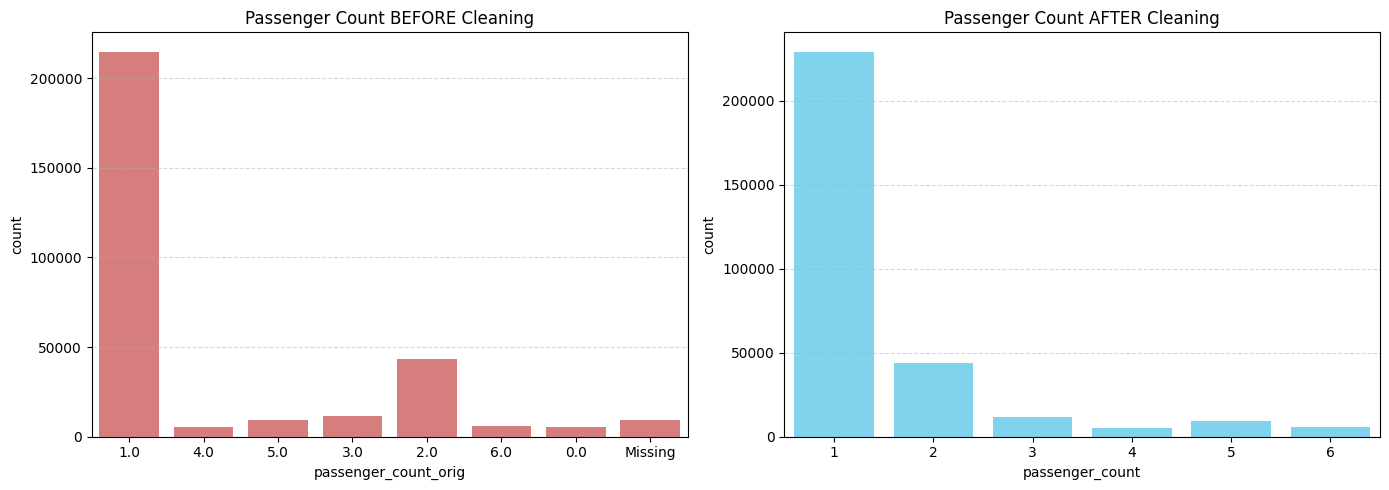

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# BEFORE Cleaning
sns.countplot(
    x=df['passenger_count_orig'].fillna('Missing'),
    color='#da3232', 
    ax=axes[0],
    alpha=0.7
)
axes[0].set_title("Passenger Count BEFORE Cleaning")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# AFTER Cleaning
sns.countplot(
    x=df['passenger_count'].fillna('Missing'),
    color='#33ccff', 
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title("Passenger Count AFTER Cleaning")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



## RatecodeID Null Imputation

### Problem:
- The `RatecodeID` column has missing values (NaNs) that represent unknown rates, potentially leading to incomplete fare structure analysis if not explicitly handled.
- Data dictionary specifies code 99 for unknowns, ensuring transparency over dropping or arbitrary fills.

### Solution Strategy:
- Directly fill all NaNs in `RatecodeID` with 99 to flag unknowns without altering valid codes.

### Results:
- Dominant code 1.0 covers 285,278 trips (standard rate), followed by imputed 99.0 at 9,781 for unknowns.
- Other codes include 2.0 at 7,389 (JFK/NYC airports), 5.0 at 1,607 (negotiated), with rare 3.0 (621), 4.0 (301), and 6.0 (1).
- Total remains 304,978, with all nulls resolved for full coverage.

In [13]:
# Preserve original
if 'RatecodeID_orig' not in df.columns:
    df['RatecodeID_orig'] = df['RatecodeID'].copy()

# Fix
df['RatecodeID'] = df['RatecodeID'].fillna(99)  # Fill nulls to 99 for transparency


print("Post-fix value_counts:")
print(df['RatecodeID'].value_counts().sort_index())


Post-fix value_counts:
RatecodeID
1.0     285278
2.0       7389
3.0        621
4.0        301
5.0       1607
6.0          1
99.0      9781
Name: count, dtype: int64


## Store and Forward Flag Cleaning

### Problem:
- The `store_and_fwd_flag` column has missing values (NaNs) that should default to 'N' per the data dictionary, indicating direct server trips rather than stored ones.
- Current string dtype ('Y' or 'N') limits boolean operations, requiring conversion for efficient analysis of offline trip flags.

### Solution Strategy:
- Fill all NaNs with 'N' to assume non-stored trips, preserving the majority direct pattern.
- Map 'Y' to True (stored and forwarded) and 'N' to False, then cast to boolean dtype for compact storage and logical queries.

### Results:
- Post-fix counts show 301,938 False (direct trips) and 3,040 True (stored trips), totaling 304,978 records with no NaNs.
- Boolean conversion enables seamless filtering, revealing ~1% of trips used store-and-forward due to connectivity issues.

In [14]:
# Preserve original
if 'store_and_fwd_flag_orig' not in df.columns:
    df['store_and_fwd_flag_orig'] = df['store_and_fwd_flag'].copy()

# Fix
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')

# change dtype to boolean
# Assuming 'Y' (stored and forwarded) → True, 'N' (direct) → False
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': True, 'N': False}).astype('bool')

print("Post-fix value_counts:")
print(df['store_and_fwd_flag'].value_counts())



Post-fix value_counts:
store_and_fwd_flag
False    301938
True       3040
Name: count, dtype: int64


### Plot Overview:
- Arranges four countplots in a 2x2 grid represent, 'RatecodeID' and 'store_and_fwd_flag' before and after cleaning step.
- **RatecodeID**: highlights standard rate 1.0 dominating at 285,278 trips, with 9,781 'Missing' but after shifts 'Missing' to a distinct 99.0 bar of equal size, preserving all valid distributions.
- **Store and forward flag**: before displays a massive 'N' bar, slim 'Y' for stored trips, and around 9.5k for 'Missing'; after merges to oversized False (301,938) and slim True (3,040).

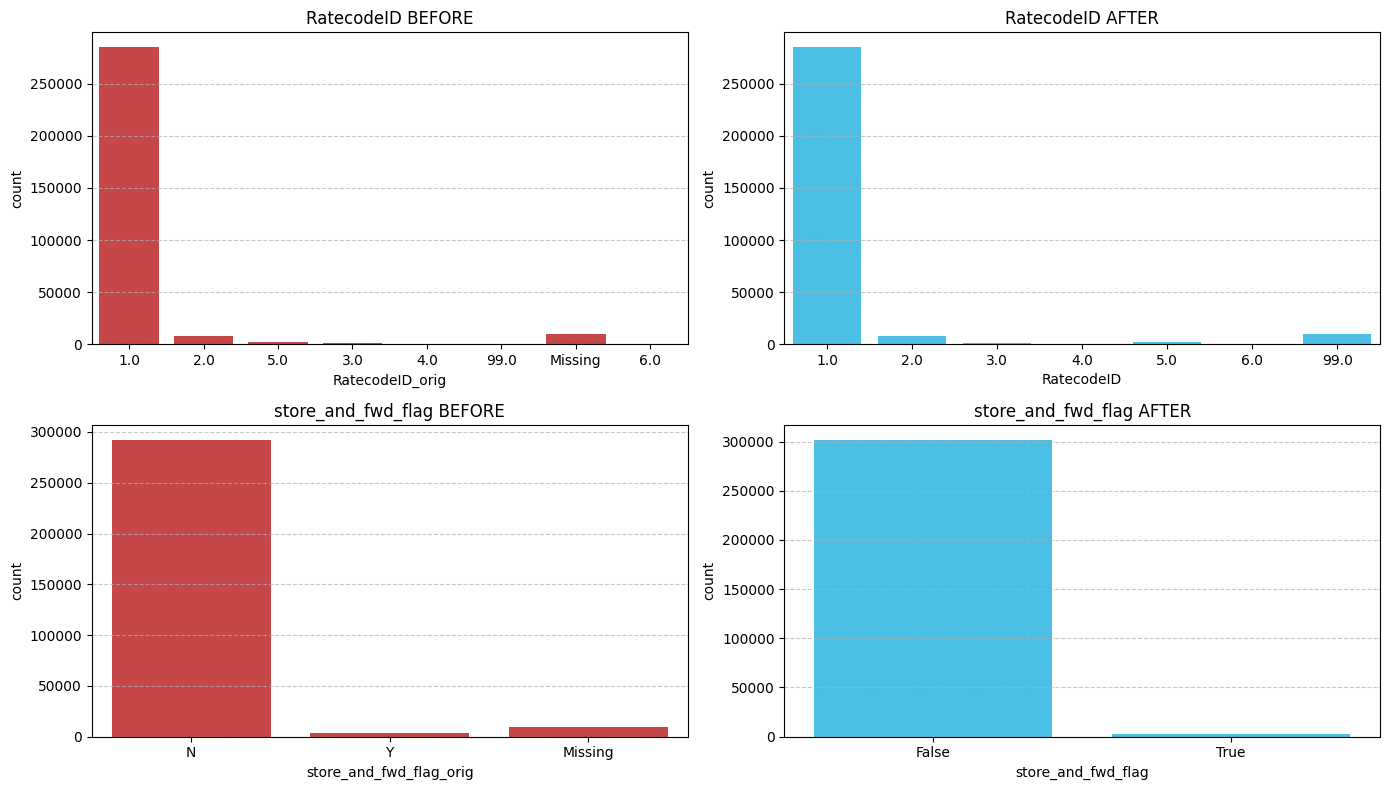

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))

# RatecodeID BEFORE
sns.countplot(
    x=df['RatecodeID_orig'].fillna('Missing'),
    color='#da3232', 
    ax=axes[0,0]
)
axes[0,0].set_title("RatecodeID BEFORE")
axes[0,0].grid(axis='y', linestyle='--', alpha=0.7)

# RatecodeID AFTER
sns.countplot(
    x=df['RatecodeID'].fillna('Missing'),
    color='#33ccff', 
    ax=axes[0,1]
)
axes[0,1].set_title("RatecodeID AFTER")
axes[0,1].grid(axis='y', linestyle='--', alpha=0.7)

# store_and_fwd_flag BEFORE
sns.countplot(
    x=df['store_and_fwd_flag_orig'].fillna('Missing'),
    color='#da3232', 
    ax=axes[1,0]
)
axes[1,0].set_title("store_and_fwd_flag BEFORE")
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)

# store_and_fwd_flag AFTER
sns.countplot(
    x=df['store_and_fwd_flag'].fillna('Missing'),
    color='#33ccff', 
    ax=axes[1,1]
)
axes[1,1].set_title("store_and_fwd_flag AFTER")
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Congestion Surcharge Initialization

### Problem:
- Yellow Taxi data from Q1 2018 falls before the June 16, 2019 implementation of congestion surcharges, so any existing `congestion_surcharge` values are invalid or absent.
- Without correction, this could inflate total fares or mislead analysis of post-2019 trip economics.

### Solution Strategy:
- We set the entire `congestion_surcharge` column to 0 to align with historical absence of the fee.
- This uniform assignment ensures consistency across the pre-implementation dataset.

### Results:
- All 304,978 trips now reflect 0 in `congestion_surcharge`, preventing erroneous additions to fare totals.

In [16]:
# Preserve original
if 'congestion_surcharge_orig' not in df.columns:
    df['congestion_surcharge_orig'] = df['congestion_surcharge'].copy()

# Fix
df["congestion_surcharge"] = 0

## Airport Fee Assignment and Correction

### Problem:
- The `airport_fee` column was erroneously reset to $0.00 across all trips, overlooking surcharges for airport zones 132 (JFK) and 138 (LGA) in the 2018 dataset.
- Lack of sign alignment with `total_amount` risks inconsistent fare totals, especially for negative (refund) trips involving airports.

### Solution Strategy:
- Identify airport trips via mask on `PULocationID` or `DOLocationID` in [132, 138], assigning 1.25 to those rows.
- For airport trips with `total_amount` < 0, override to -1.25 to match negative totals, ensuring logical fee polarity.

### Results:
- Non-airport trips stay at 0, while airport-involved ones (PU or DO in zones) receive 1.25, with negatives flipped to -1.25 where applicable.

In [17]:
# Preserve original
if 'airport_fee_orig' not in df.columns:
    df['airport_fee_orig'] = df['airport_fee'].copy()

# Fix 
df['airport_fee'] = 0  # Reset all
df['airport_fee'] = df['airport_fee'].astype(float)
airport_zones = [132, 138]

mask_airport = ((df['PULocationID'].isin(airport_zones)) | (df['DOLocationID'].isin(airport_zones))) 
df.loc[mask_airport, 'airport_fee'] = 1.25

mask_negative_total = mask_airport & (df['total_amount'] < 0)
df.loc[mask_negative_total, 'airport_fee'] = -1.25


## Improvement Surcharge Assignment

### Problem:
- The `improvement_surcharge` column requires standardization to $0.30 for all trips post-2015 (including Q1 2018 data).
- Negative `total_amount` entries demand corresponding negative surcharges to maintain fare logic, avoiding overstatement of costs.

### Solution Strategy:
- Reset the entire `improvement_surcharge` column to 0.3 and cast to float for uniform application.
- Identify rows with `total_amount` < 0 and override those surcharges to -0.3 for sign consistency.

### Results:
- Most trips now default to 0.3, reflecting the standard flag-drop fee levied since 2015.
- A small subset with negative totals (e.g., refunds) adjusts to -0.3, ensuring balanced total_amount calculations across the dataset.

In [18]:
# Preserve original
if 'improvement_surcharge_orig' not in df.columns:
    df['improvement_surcharge_orig'] = df['improvement_surcharge'].copy()

# Fix
df['improvement_surcharge'] = 0.3  # Reset all
df['improvement_surcharge'] = df['improvement_surcharge'].astype(float)

mask_negative_total = df['total_amount'] < 0
df.loc[mask_negative_total, 'improvement_surcharge'] = -0.3

## MTA Tax Assignment

### Problem:
- The `mta_tax` column needs to default to $0.50 for standard metered NYC taxi trips, but must be adjusted for negative `total_amount` (refunds) and exempted for non-NYC (RatecodeID=4) or EWR (LocationID=1) trips to avoid overtaxing.

### Solution Strategy:
- Initialize all `mta_tax` to 0.5 as float, then set to -0.5 for rows where `mask_negative_total` (negative `total_amount`) applies.
- Zero out for `RatecodeID` == 4 (trips outside NYC) and for PU/DO at LocationID=1 (EWR airport trips).

### Results:
- Majority of 304,978 trips retain 0.5 (or -0.5 for negatives), accurately reflecting metered tax.
- Exemptions apply to RatecodeID=4 trips and EWR-involved ones, setting them to 0 for policy compliance.


In [19]:
# Preserve original
if 'mta_tax_orig' not in df.columns:
    df['mta_tax_orig'] = df['mta_tax'].copy()

# Fix
df['mta_tax'] = 0.5  # Reset all
df['mta_tax'] = df['mta_tax'].astype(float)

df.loc[mask_negative_total, 'mta_tax'] = -0.5

mask_ratecode_4 = df['RatecodeID'] == 4                                # Nassau/Westchester: trip outside NYC (RatecodeID = 4)
df.loc[mask_ratecode_4, 'mta_tax'] = 0.0

mask_EWR = ((df['PULocationID'] ==1) | (df['DOLocationID']==1))        #Trips to/from EWR (LocationID = 1)
df.loc[mask_EWR, 'mta_tax'] = 0

## Trip Distance Anomaly Detection and Imputation

### Problem:
- Negative `trip_distance` values and zeros for trips without no-charge payment type(payment_type != 3) indicate data errors, while extremes beyond the 99th percentile (19.54 miles) suggest unrealistic long hauls.
- These anomalies skew distance-based metrics like average trip length across 304,978 records, requiring preservation of originals for validation.

### Solution Strategy:
- Calculate 99th percentile on positive distances, then mask anomalies as negatives, zero but not no-charge, or >19.54 miles.
- From clean subset (positive distance/duration, no anomalies), derive `speed_mph` and compute mean speeds grouped by `similar_groups` (VendorID, PULocationID, DOLocationID, time_bucket), with global mean fallback.
- Impute anomalies using `min(group mean speed or global, capped at 60 mph) * (trip_duration / 60)`, enforce min 0.01, set payment_type=3 for fixed zeros, and drop temp column.

### Results:
- Post-fix summary shows mean distance at 3.09 miles (down from pre-fix skew), std 3.84, with min 0 (valid no-charges) and max capped at 61.07 miles from speed limit.

In [20]:
# 99th percentile for distance
dist_99 = df.loc[df['trip_distance'] > 0, 'trip_distance'].quantile(0.99)

print(f"99th percentile distance: {dist_99}")

# Detect anomalies
anomaly_mask = (
    (df['trip_distance'] < 0) |                                   # all negative
    ((df['trip_distance'] == 0) & (df['payment_type'] != 3)) |    # zero but not no-charge
    (df['trip_distance'] > dist_99)                               # too long
)

# Preserve original
if 'trip_distance_orig' not in df.columns:
    df['trip_distance_orig'] = df['trip_distance'].copy()

# Fix (speed imputation)
clean_mask = (df['trip_distance'] > 0) & (df['trip_duration'] > 0) & ~anomaly_mask
df_clean = df.loc[clean_mask].copy()
df_clean['speed_mph'] = df_clean['trip_distance'] / (df_clean['trip_duration'] / 60)
mean_speed = df_clean.groupby(similar_groups)['speed_mph'].mean()
global_mean_speed = df_clean['speed_mph'].mean()

apply_cols = similar_groups + ['trip_duration']
df['imputed_dist'] = df[apply_cols].apply(
    lambda x: min(mean_speed.get((x.iloc[0], x.iloc[1], x.iloc[2], x.iloc[3]), global_mean_speed), 60) * (x.iloc[4] / 60), axis=1
)
df.loc[anomaly_mask, 'trip_distance'] = np.maximum(df.loc[anomaly_mask, 'imputed_dist'], 0.01)
df.loc[(df['trip_distance'] == 0 ) & (df['payment_type'] != 3), 'payment_type'] = 3
df.drop(columns=['imputed_dist'], inplace=True, errors='ignore')


print("Post-fix describe:")
print(df['trip_distance'].describe())

99th percentile distance: 19.54
Post-fix describe:
count    304978.000000
mean          3.086374
std           3.837071
min           0.000000
25%           1.020000
50%           1.750000
75%           3.260000
max          61.066667
Name: trip_distance, dtype: float64


### Plot Overview:
- The scatterplot illustrates points form a tight linear cluster with positive slope, indicating strong correlation where longer distances correspond to longer durations, typical of taxi trips at average speeds around 15-20 mph.
- Log scaling compresses the range (distances 0.01-61 miles, durations 0-61 min). 
- Tight linear cluster with positive slope: The dense blue cloud follows a clear upward-right diagonal (slope ≈1 on log-log, implying proportional relationship), confirming strong positive correlation

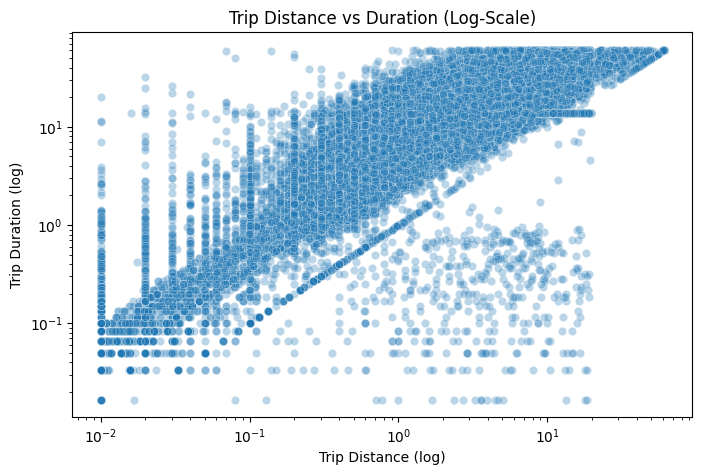

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='trip_distance', y='trip_duration',
    data=df, alpha=0.3
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Trip Distance (log)")
plt.ylabel("Trip Duration (log)")
plt.title("Trip Distance vs Duration (Log-Scale)")
plt.show()


## Payment Type and Tip Amount Correction

### Problem:
- 614 rows show invalid `payment_type` (0,4,5,6,99) paired with negative or zero `total_amount`, which should restrict to valid 1 (credit), 2 (cash), or 3 (no charge) for logical consistency.
- Non-zero `tip_amount` persists for cash payments (type 2), inflating totals where tips aren't applicable.

### Solution Strategy:
- Detect invalids as neg/zero totals outside [1,2,3].
- Impute via mode from grouped `VendorID` and `RatecodeID` (fallback 1), force to [1,2,3] by mapping others to 1 (credit default).
- Zero out `tip_amount` for all `payment_type` == 2 to enforce no-tip cash policy.

### Results:
- Imputation resolves all 614 invalids, yielding 652 credit (1), 246 cash (2), and 347 no-charge (3) for neg/zero totals, achieving 100% validity.
- Tip adjustments set cash payments to 0.00 (6 cases dominant), from tips from 1.00 to 12.05.

In [22]:
# Preserve original
if 'payment_type_orig' not in df.columns:
    df['payment_type_orig'] = df['payment_type'].copy()
if 'tip_amount_orig' not in df.columns:
    df['tip_amount_orig'] = df['tip_amount'].copy()


# Detect
neg_zero_total = df['total_amount'] <= 0
invalid_ptype = neg_zero_total & ~df['payment_type'].isin([1, 2, 3])  # Flag 0,4,5,6,99
print(f"Detected invalid payment_types for neg/zero total: {invalid_ptype.sum()} rows")


# Fix: Impute mode from VendorID + RatecodeID, then force to [1,2,3]
group_mode = df.groupby(['VendorID', 'RatecodeID'])['payment_type'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 1)
imputed = df.loc[invalid_ptype, ['VendorID', 'RatecodeID']].apply(
    lambda row: group_mode.get((row['VendorID'], row['RatecodeID']), 1), axis=1
)
# Force to valid [1,2,3]: If mode invalid (0,4,5,6,99), map to 1 (credit fallback)
imputed = imputed.apply(lambda p: p if p in [1,2,3] else 1)
df.loc[invalid_ptype, 'payment_type'] = imputed

print("Post-fix payment_type for neg/zero total:")
print(df[neg_zero_total]['payment_type'].value_counts().sort_index())
print(f"Valid [1,2,3] % in neg/zero: {(df[neg_zero_total]['payment_type'].isin([1,2,3])).mean() * 100:.2f}%")


# Set tip_amount = 0 for cash payments
print("Non-fix cash payment and tip amount:")
print(df.loc[df['payment_type'] == 2, 'tip_amount'].value_counts().sort_index())

df.loc[df['payment_type'] == 2, 'tip_amount'] = 0



Detected invalid payment_types for neg/zero total: 614 rows
Post-fix payment_type for neg/zero total:
payment_type
1    652
2    246
3    347
Name: count, dtype: int64
Valid [1,2,3] % in neg/zero: 100.00%
Non-fix cash payment and tip amount:
tip_amount
0.00     75893
1.00         1
1.06         1
1.70         1
3.08         1
3.16         1
12.05        1
Name: count, dtype: int64


## Sign Consistency Enforcement for Fare Components

### Problem:
- Negative `total_amount` values, valid for refunds or voids in NYC taxi data, often pair with positive components like `fare_amount` or `tip_amount`, violating financial breakdown logic.
- This anomaly affects transaction integrity, potentially leading to erroneous aggregations or modeling errors across the dataset.

### Solution Strategy:
- For rows with `total_amount` < 0, negate the absolute values of these components; for positive totals, enforce absolute values to eliminate any stray negatives.

### Results:
- All specified components now align in sign with `total_amount`, ensuring sum consistency for refunds (e.g., negative fares) and standard trips alike.

In [23]:
# Columns to clean
sign_col = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge']

# Preserve originals
for feature in sign_col:
    if f'{feature}_orig' not in df.columns:
        df[f'{feature}_orig'] = df[feature].copy()

# Force sign consistency 
negative_total = df['total_amount'] < 0
df.loc[negative_total, sign_col] = -df.loc[negative_total, sign_col].abs()
df.loc[~negative_total, sign_col] = df.loc[~negative_total, sign_col].abs()


## Amount Columns Anomaly Imputation

### Problem:
- Continuous fare components like `fare_amount`, `extra`, `tip_amount`, and `tolls_amount` exhibit positive outliers above the 99th percentile and negative extremes below the 1st percentile, distorting means (e.g., `fare_amount` pos mean 13.10 initially skewed by 3011 anomalies).
- These inconsistencies in 304,978 trips undermine financial accuracy, especially for sign-specific breakdowns in refunds versus standard fares.

### Solution Strategy:
- Detect anomalies separately for positives (>99th quantile) and negatives (<1st quantile) per column.
- From non-anomalous subsets, calculate means grouped by `similar_groups` (VendorID, PULocationID, DOLocationID, time_bucket) with global fallbacks, imputing anomalies using sign-matched values via temporary columns.
- Output anomaly counts, post-fix describe summaries, sign-specific means, and negative imputation validation for each of the four columns.

### Results:
- `fare_amount`: Fixed 3011 pos and 12 neg anomalies; post-fix mean 13.00, std 10.64, range -67 to 57, with 100% neg imputations negative.
- `extra`: Addressed 1012 pos and 3 neg; mean 0.89, std 1.15, range -4.5 to 4.5, pos mean 1.61, neg mean -0.82, 100% neg success.
- `tip_amount`: Corrected 2125 pos and 1 neg; mean 2.14, std 2.36, range -20 to 14, pos mean 3.07, neg mean -3.97, 100% neg success.
- `tolls_amount`: Handled 172 pos and 0 neg; mean 0.38, std 1.62, range -13.75 to 19, pos mean 6.59, neg mean -7.40.

In [24]:
def clean_amount_column(df, col_name, similar_groups):
    """
    Clean a continuous amount columns by imputing anomalies with means from similar non-anomalous trips (pos/neg separated).
    
    Parameters:
    - df: Our current dataset.
    - col_name: ['fare_amount', 'extra', 'tip_amount', 'tolls_amount'].
    - similar_groups: ['VendorID','PULocationID', 'DOLocationID', 'time_bucket'].
    """
    # Preserve original
    orig_col = f'{col_name}_orig'
    if orig_col not in df.columns:
        df[orig_col] = df[col_name].copy() 
     
    # Detect anomalies per sign
    neg_mask = df[col_name] < 0
    pos_mask = df[col_name] > 0
    pos_q99 = df.loc[pos_mask, col_name].quantile(0.99) if pos_mask.sum() > 0 else 0
    neg_q01 = df.loc[neg_mask, col_name].quantile(0.01) if neg_mask.sum() > 0 else 0
    
    pos_anomaly = pos_mask & (df[col_name] > pos_q99)
    neg_anomaly = neg_mask & (df[col_name] < neg_q01)
    anomaly_mask = pos_anomaly | neg_anomaly
    print(f"Detected pos anomalies for {col_name}: {pos_anomaly.sum()}, neg anomalies: {neg_anomaly.sum()}")
    

    # Find means from similar non-anomalous trips (separate for pos/neg)
    # Pos: Only non-anomaly positives
    pos_clean_mask = pos_mask & ~pos_anomaly
    pos_clean = df.loc[pos_clean_mask].copy()
    mean_pos_similar = pos_clean.groupby(similar_groups)[col_name].mean()
    global_mean_pos = pos_clean[col_name].mean() if not pos_clean.empty else df.loc[pos_mask, col_name].mean()
    
    # Neg: Only non-anomaly negatives
    neg_clean_mask = neg_mask & ~neg_anomaly
    neg_clean = df.loc[neg_clean_mask].copy()
    mean_neg_similar = neg_clean.groupby(similar_groups)[col_name].mean()
    global_mean_neg = neg_clean[col_name].mean() if not neg_clean.empty else df.loc[neg_mask, col_name].mean()
    
    # Step 4: Impute anomalies with cluster-specific means (group fallback to global)
    pos_temp_col = f'imputed_{col_name}_pos'
    neg_temp_col = f'imputed_{col_name}_neg'
    df[pos_temp_col] = df[similar_groups].apply(
        lambda x: mean_pos_similar.get(tuple(x), global_mean_pos), axis=1
    )
    df[neg_temp_col] = df[similar_groups].apply(
        lambda x: mean_neg_similar.get(tuple(x), global_mean_neg), axis=1
    )
    
    df.loc[pos_anomaly, col_name] = df.loc[pos_anomaly, pos_temp_col]
    df.loc[neg_anomaly, col_name] = df.loc[neg_anomaly, neg_temp_col]
    
    df.drop(columns=[pos_temp_col, neg_temp_col], inplace=True, errors='ignore')
    
    # Print summaries
    print(f"Post-fix describe for {col_name}:")
    print(df[col_name].describe())
    print(f"Pos mean: {df.loc[pos_mask, col_name].mean():.2f}, Neg mean: {df.loc[neg_mask, col_name].mean():.2f}")
    if neg_anomaly.sum() > 0:
        print(f"Neg anomalies imputed with neg values %: {(df.loc[neg_anomaly, col_name] < 0).mean() * 100:.2f}%")
    print()  # Blank line for readability


amount_features = ['fare_amount', 'extra', 'tip_amount', 'tolls_amount']

for col in amount_features:
    clean_amount_column(df, col, similar_groups)

Detected pos anomalies for fare_amount: 3011, neg anomalies: 12
Post-fix describe for fare_amount:
count    304978.000000
mean         12.997863
std          10.643196
min         -67.000000
25%           6.500000
50%           9.500000
75%          15.000000
max          57.000000
Name: fare_amount, dtype: float64
Pos mean: 13.10, Neg mean: -11.52
Neg anomalies imputed with neg values %: 100.00%

Detected pos anomalies for extra: 1012, neg anomalies: 3
Post-fix describe for extra:
count    304978.000000
mean          0.891784
std           1.151026
min          -4.500000
25%           0.000000
50%           0.500000
75%           1.000000
max           4.500000
Name: extra, dtype: float64
Pos mean: 1.61, Neg mean: -0.82
Neg anomalies imputed with neg values %: 100.00%

Detected pos anomalies for tip_amount: 2125, neg anomalies: 1
Post-fix describe for tip_amount:
count    304978.000000
mean          2.143272
std           2.355297
min         -20.000000
25%           0.000000
50%     

### Plot Overview:
- Before cleaning, histograms reveal right-skewed tails with outliers (e.g., fare_amount extending beyond 50, tips up to 20+), inflating means like 13+ for fare and causing sparse high bins; after, tails truncate (e.g., fare max ~57), concentrating ~75% under 15 for fares and 5 for tips.

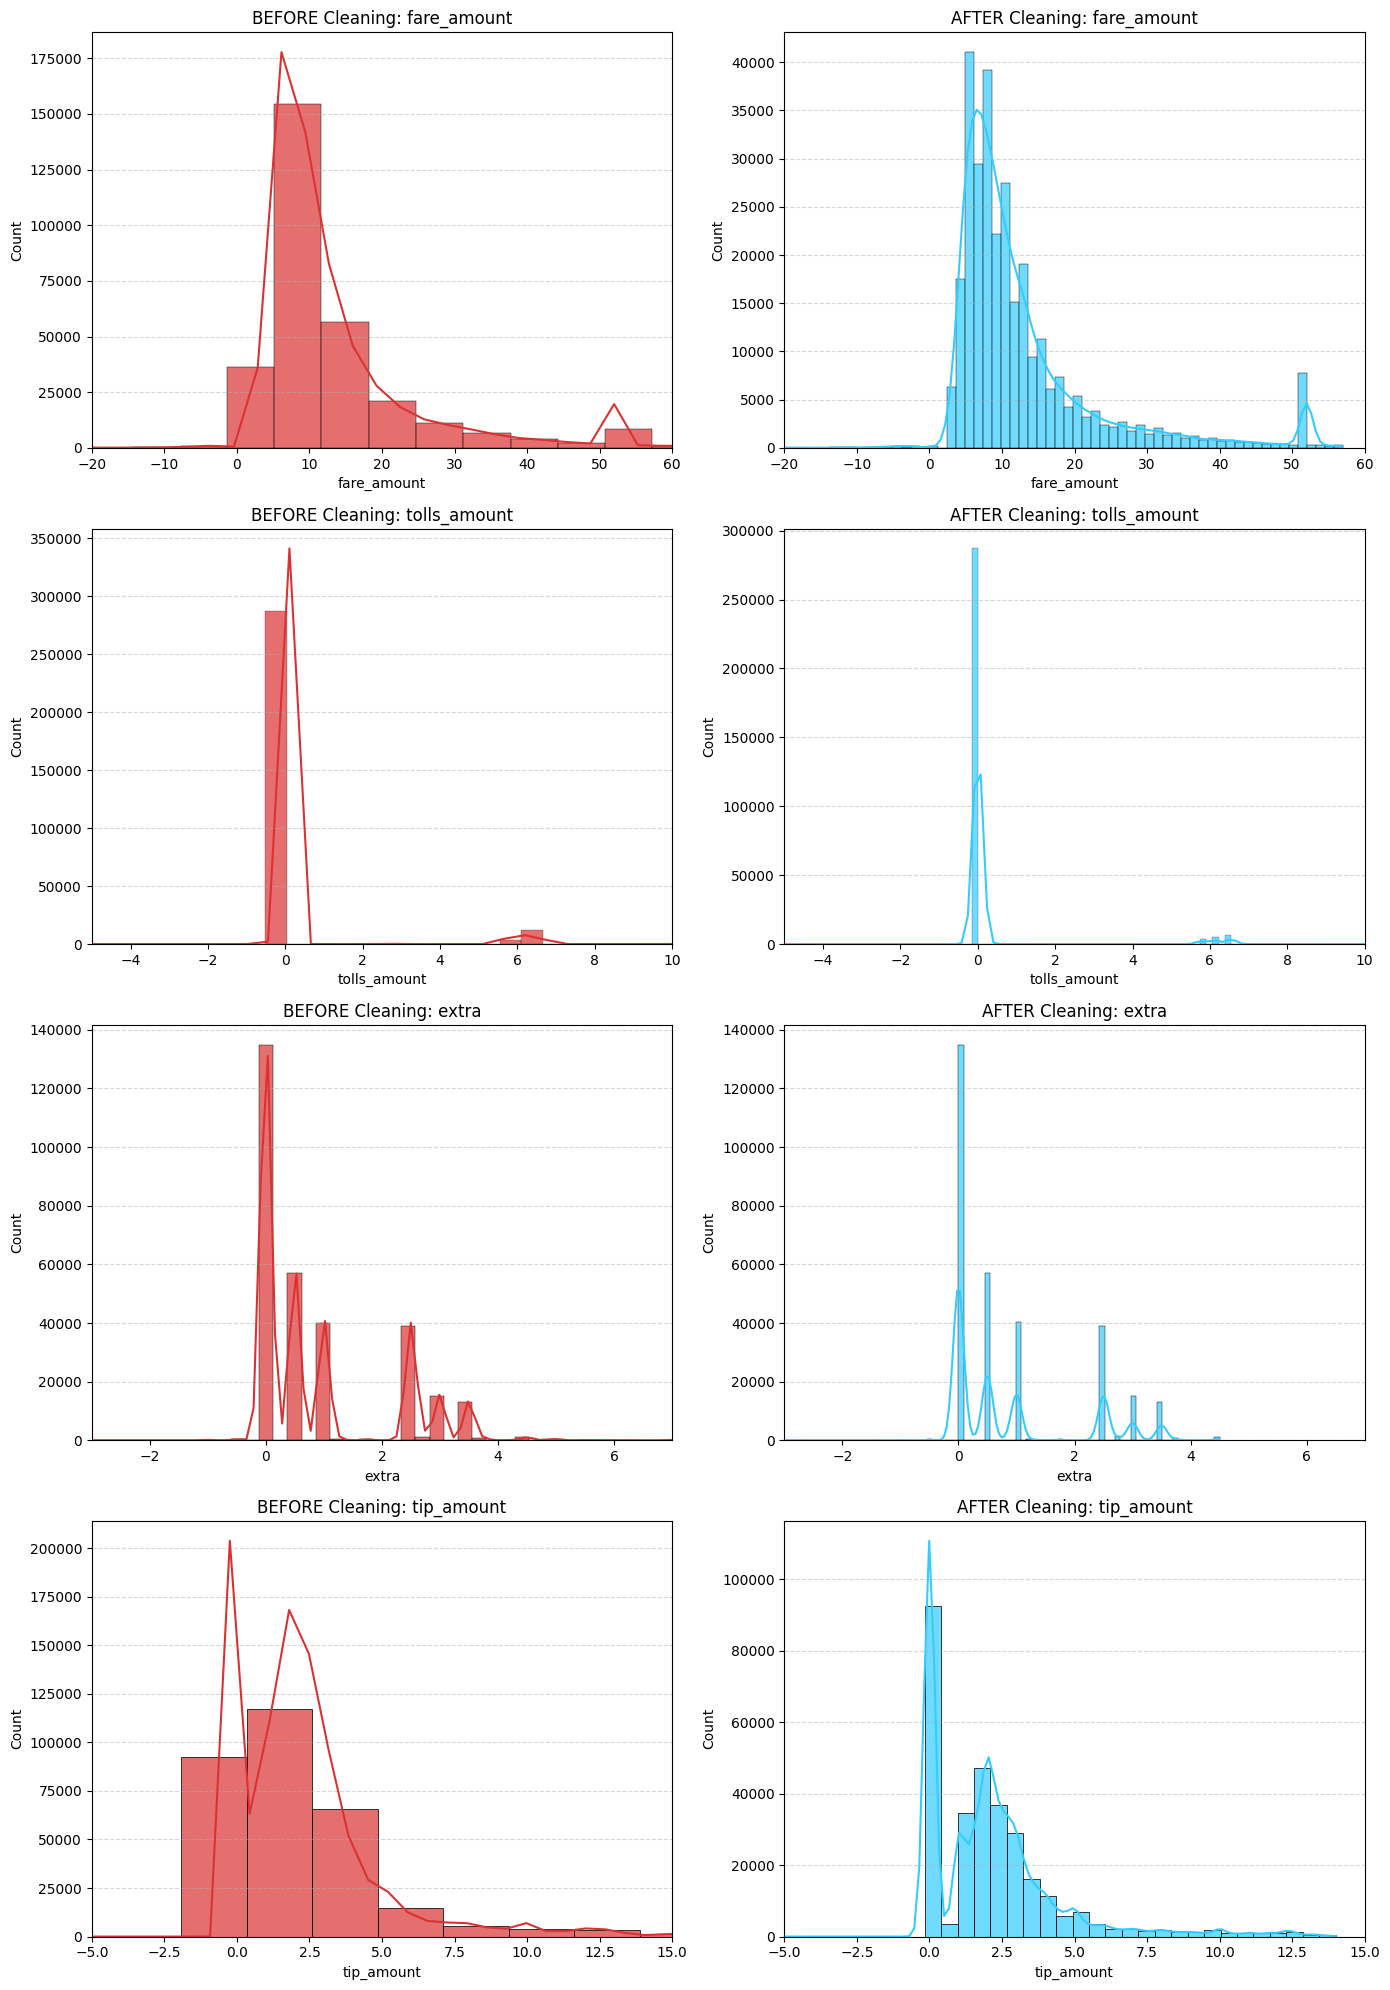

In [25]:
features = ['fare_amount', 'tolls_amount', 'extra', 'tip_amount']
bins_dict = {
    'fare_amount': 100,
    'tolls_amount': 200,
    'extra': 100,
    'tip_amount': 60
}
xlim_dict = {
    'fare_amount': (-20, 60),
    'tolls_amount': (-5, 10),
    'extra': (-3, 7),
    'tip_amount': (-5, 15)
}

fig, axes = plt.subplots(len(features), 2, figsize=(14, 20))

for i, feature in enumerate(features):
    # BEFORE Cleaning
    sns.histplot(
        df[f"{feature}_orig"],
        bins=bins_dict[feature],
        kde=True,
        color="#da3232",
        alpha=0.7,
        ax=axes[i,0]
    )
    axes[i,0].set_title(f"BEFORE Cleaning: {feature}", fontsize=12)
    axes[i,0].set_xlabel(feature)
    axes[i,0].set_ylabel("Count")
    axes[i,0].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i,0].set_xlim(xlim_dict[feature])

    # AFTER Cleaning
    sns.histplot(
        df[feature],
        bins=bins_dict[feature],
        kde=True,
        color="#33ccff",
        alpha=0.7,
        ax=axes[i,1]
    )
    axes[i,1].set_title(f"AFTER Cleaning: {feature}", fontsize=12)
    axes[i,1].set_xlabel(feature)
    axes[i,1].set_ylabel("Count")
    axes[i,1].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i,1].set_xlim(xlim_dict[feature])

plt.tight_layout()
plt.show()


### Plot Overview:
- Before cleaning, boxes reveal wide spreads and numerous fliers (e.g., fare_amount whiskers beyond 50 with extremes >100, tip_amount negatives and highs >20), inflating variability; after, outliers reduce sharply (fare max 57, tip max 14), tightening boxes around medians like 9.5 for fare and 0 for tolls/extra.
- Deterministic features like `mta_tax` (median 0.5, whiskers at 0/-0.5) and `improvement_surcharge` (median 0.3, narrow at ±0.3) show minimal change, confirming policy-based fixes, while imputed ones like `tip_amount` shift medians to 1.86 with fewer negatives.

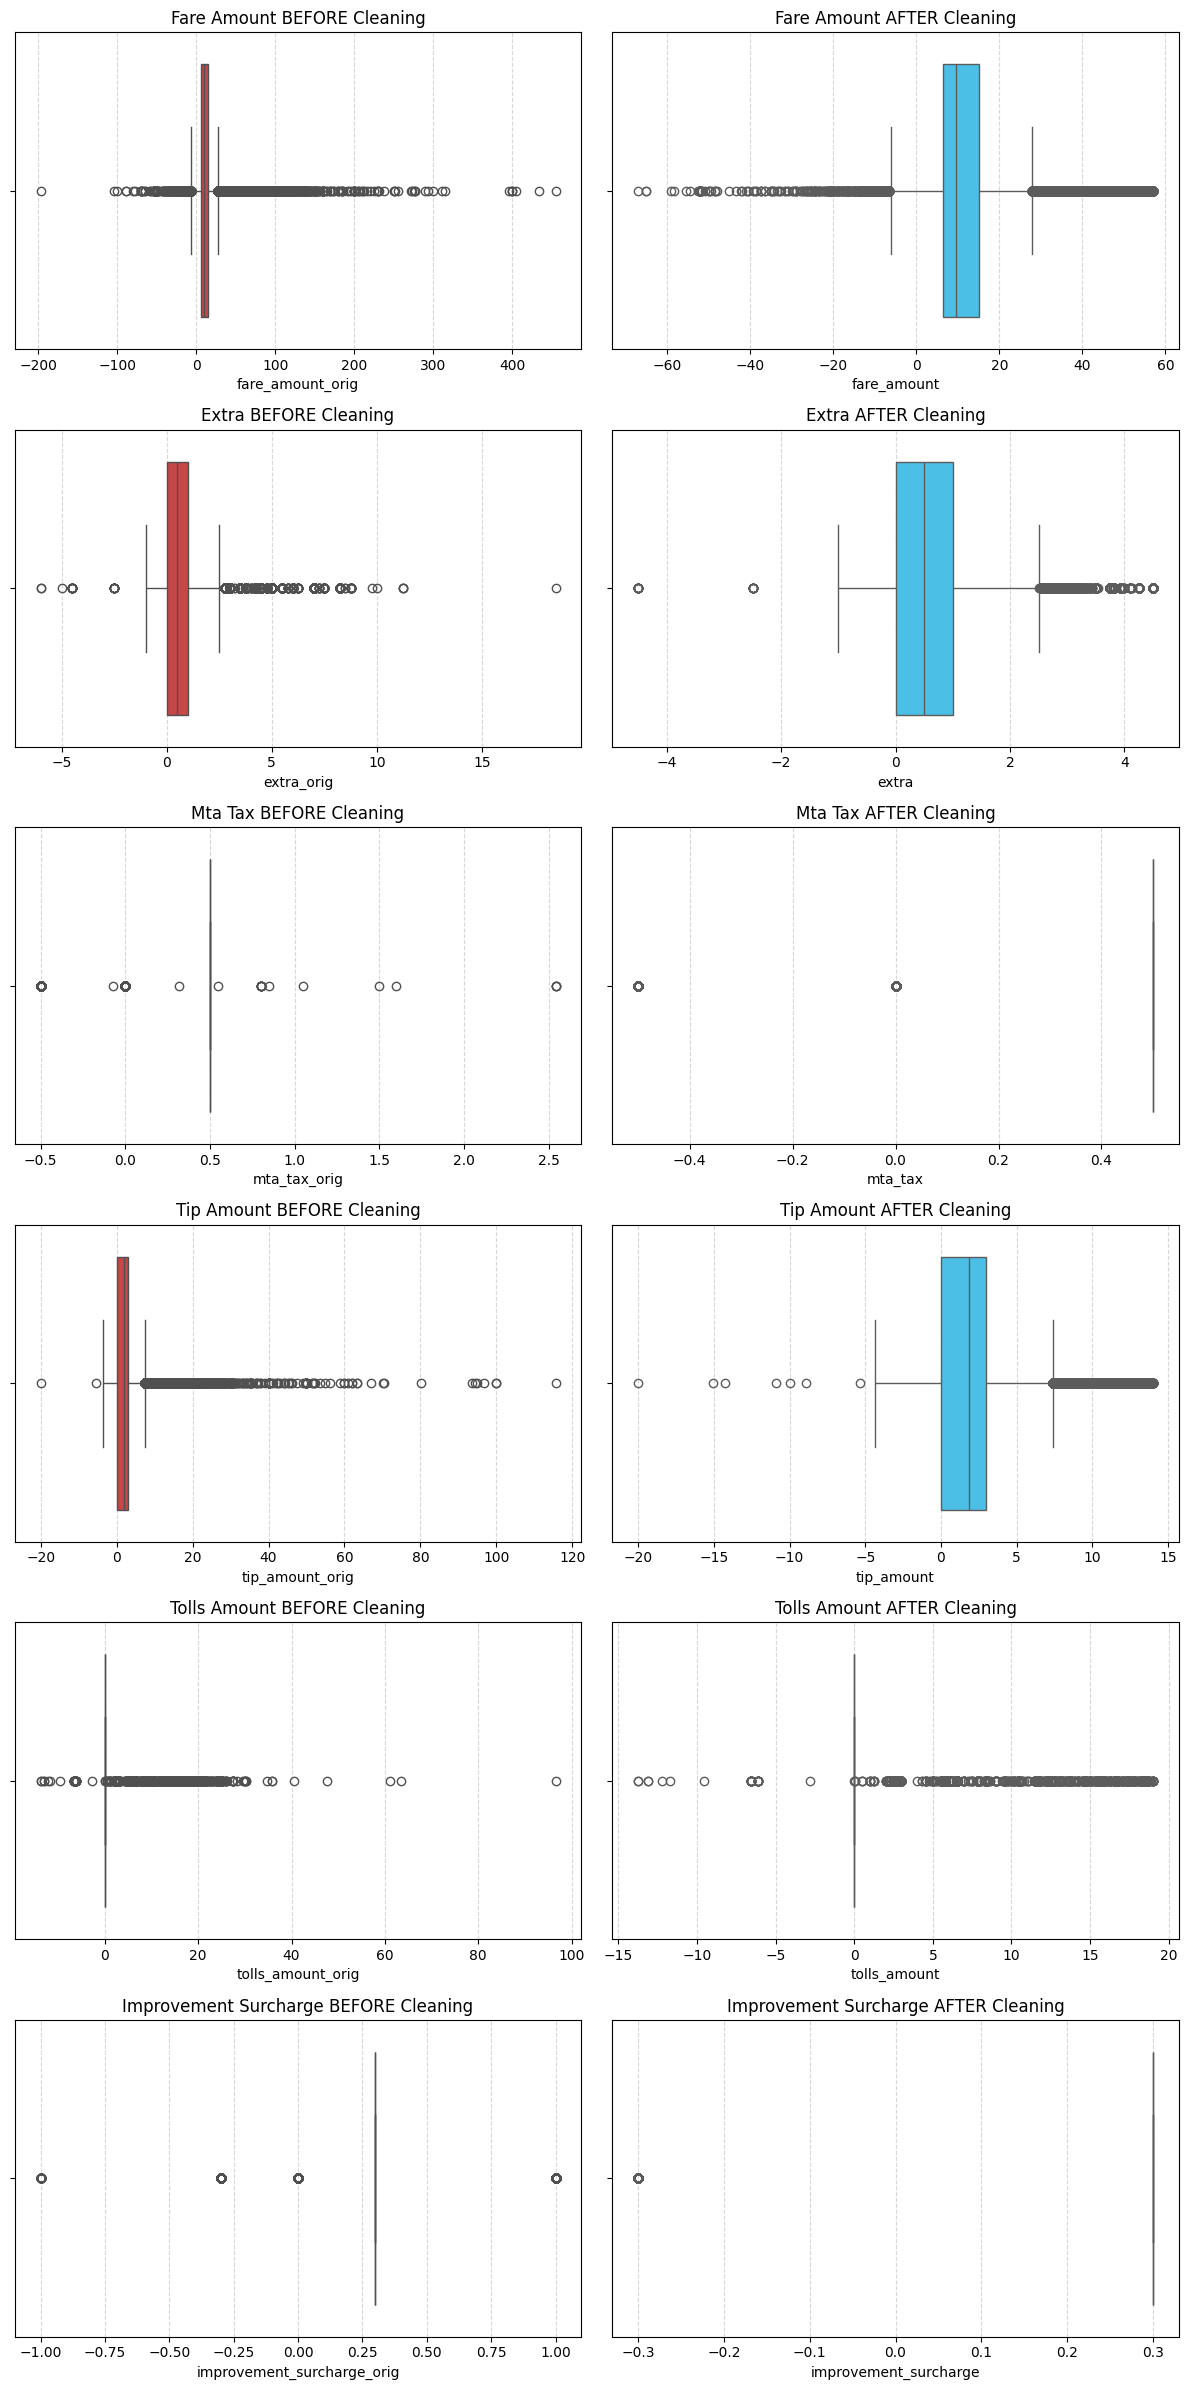

In [26]:
amount_features = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge']
before_color = '#da3232'
after_color = '#33ccff'

fig, axes = plt.subplots(len(amount_features), 2, figsize=(12, 4*len(amount_features)))

for i, feature in enumerate(amount_features):
    # BEFORE Cleaning
    sns.boxplot(x=df[f'{feature}_orig'], ax=axes[i,0], color=before_color, showfliers=True)
    axes[i,0].set_title(f"{feature.replace('_',' ').title()} BEFORE Cleaning")
    axes[i,0].grid(axis='x', linestyle='--', alpha=0.5)

    # AFTER Cleaning
    sns.boxplot(x=df[feature], ax=axes[i,1], color=after_color, showfliers=True)
    axes[i,1].set_title(f"{feature.replace('_',' ').title()} AFTER Cleaning")
    axes[i,1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## JFK Flat Rate Amount Adjustment

### Problem:
- For RatecodeID 2 trips (7,389 total JFK flat-rate rides), `fare_amount` varies inconsistently instead of standardizing to $52, including positives below/above and negatives not mirrored, which disrupts fare accuracy.
- Original values need preservation to audit changes, especially since prior cleaning may have already adjusted some.

### Solution Strategy:
- Identify RatecodeID==2 rows, then subset by `total_amount` sign: positive (>0), negative (<0), and zero (==0).
- Set `fare_amount` to 52 for positives and -52 for negatives, leaving zeros unchanged per request, after backing up to `fare_amount_orig` if missing.

### Results:
- Post-fix distribution: 7,313 at 52.0, 71 at -52.0, and 5 at 0.0, fully aligning with JFK policy across the 7,389 affected trips.
- Ensures sign consistency with totals, preventing over/underestimation in fare breakdowns for airport routes.

In [27]:
# New Step: fare_amount for RatecodeID 2 (JFK flat rate)
# Detect
rate2_mask = df['RatecodeID'] == 2

# Preserve original
if 'fare_amount_orig' not in df.columns:
    df['fare_amount_orig'] = df['fare_amount'].copy()

# Fix: Adjust based on total_amount sign
positive_total = rate2_mask & (df['total_amount'] > 0)
negative_total = rate2_mask & (df['total_amount'] < 0)
zero_total = rate2_mask & (df['total_amount'] == 0)

df.loc[positive_total, 'fare_amount'] = 52
df.loc[negative_total, 'fare_amount'] = -52
# Zero total: No change (as requested)


print("Post-fix fare_amount for Ratecode 2:")
print(df[rate2_mask]['fare_amount'].value_counts().sort_index())
print(f"Positive totals set to 52: {positive_total.sum()}")
print(f"Negative totals set to -52: {negative_total.sum()}")
print(f"Zero totals unchanged: {zero_total.sum()}")

Post-fix fare_amount for Ratecode 2:
fare_amount
-52.0      71
 0.0        5
 52.0    7313
Name: count, dtype: int64
Positive totals set to 52: 7313
Negative totals set to -52: 71
Zero totals unchanged: 5


### Plot Overview:
- Before cleaning, the distribution scatters across -70 (3 trips), -52 (63), 0 (12), 52 (7045 dominant), plus outliers at 68.56 (1) and 70 (265), reflecting inconsistent JFK flat-rate recordings.
- After cleaning, it consolidates to sharp peaks at -52 (71 negatives), 0 (5 zeros unchanged), and 52 (7313 positives), enforcing policy standardization.

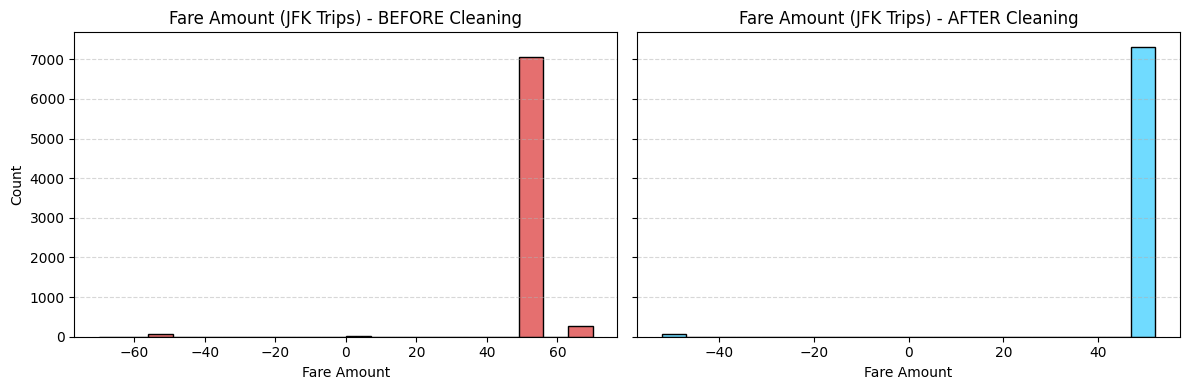

In [28]:
before_color = '#da3232'  # before cleaning
after_color  = '#33ccff'  # after cleaning

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# BEFORE cleaning
sns.histplot(df.loc[df['RatecodeID_orig']==2, 'fare_amount_orig'],
             bins=20, color=before_color, alpha=0.7, ax=axes[0])
axes[0].set_title("Fare Amount (JFK Trips) - BEFORE Cleaning")
axes[0].set_xlabel("Fare Amount")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# AFTER cleaning
sns.histplot(df.loc[df['RatecodeID']==2, 'fare_amount'],
             bins=20, color=after_color, alpha=0.7, ax=axes[1])
axes[1].set_title("Fare Amount (JFK Trips) - AFTER Cleaning")
axes[1].set_xlabel("Fare Amount")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Adjusted Total Amount Calculation

- Original `total_amount` may contain unparsed extras or pre-clean inconsistencies, requiring a reconstructed version from verified components for accurate fare validation.
- This ensures alignment post-cleaning without relying on potentially flawed totals.

In [29]:
df['adj_total_amount'] = (df['fare_amount'] + df['extra'] + df['mta_tax'] + df['tip_amount'] + df['tolls_amount'] +
                          df['improvement_surcharge'] + df['congestion_surcharge'] + df['airport_fee'])

### Plot Overview:
- Before cleaning, the distribution skews right with heavy tails (mean 19.05, std 15.46, min -198.55, max 561.49), showing outliers like high fares over 100 and deep negatives distorting the bulk around 10-20.
- After adjustment, it tightens (mean 17.30, std 13.33, min -87.98, max 90.44), with 75% under 19.34 and median 13.12, reflecting accurate component sums without inflated extremes.

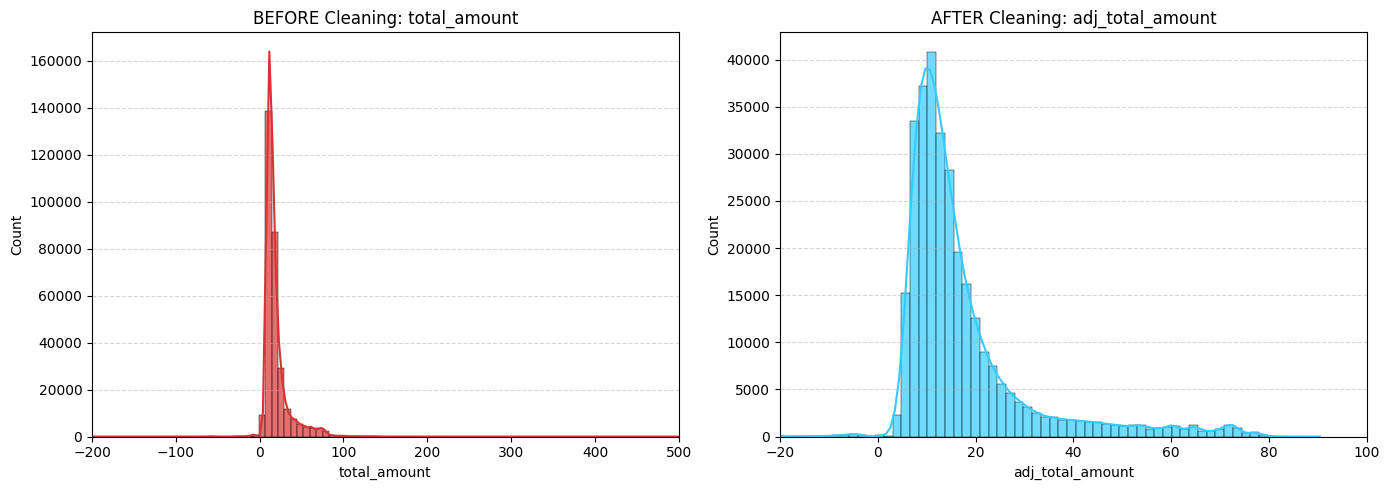

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# BEFORE Cleaning (if _orig exists)
if 'total_amount' in df.columns:
    sns.histplot(
        df['total_amount'],
        bins=100,
        kde=True,
        color="#da3232",
        alpha=0.7,
        ax=axes[0]
    )
    axes[0].set_title("BEFORE Cleaning: total_amount", fontsize=12)
    axes[0].set_xlabel("total_amount")
    axes[0].set_ylabel("Count")
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    axes[0].set_xlim(-200, 500)  # Adjust based on your data

# AFTER Cleaning
sns.histplot(
    df['adj_total_amount'],
    bins=100,
    kde=True,
    color="#33ccff",
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("AFTER Cleaning: adj_total_amount", fontsize=12)
axes[1].set_xlabel("adj_total_amount")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_xlim(-20, 100)  # Same x-limit as before

plt.tight_layout()
plt.show()

# Visualization

## Top 20 Most Frequent Pickup → Dropoff Trips

### Plot Overview:
- Horizontal bar chart using seaborn barplot on top_trips DataFrame, with trip counts on x-axis (up to ~2000) and route labels (e.g., "237 → 236") on y-axis
- Emphasizes frequency without geographic mapping, focusing on zone pair popularity.

### Insights:
- The most popular route is 237 → 236 (2069 trips), a likely Midtown Manhattan back-and-forth, followed by intra-zone 264 → 264 (1939, possibly Times Square loop) and reciprocal 236 → 237 (1673).
- Short, reciprocal urban hops dominate (e.g., 236 ↔ 237, 237 → 237 at 1422), accounting for ~10% of top volume, indicating high-demand airport/Midtown shuttles.
- Airport-adjacent zones like 239 → 238 (863, near LaGuardia) and 161 → 237 (756, Manhattan to Midtown) highlight commuter patterns, with totals for top 20 exceeding 15,000 trips or ~5% of dataset.

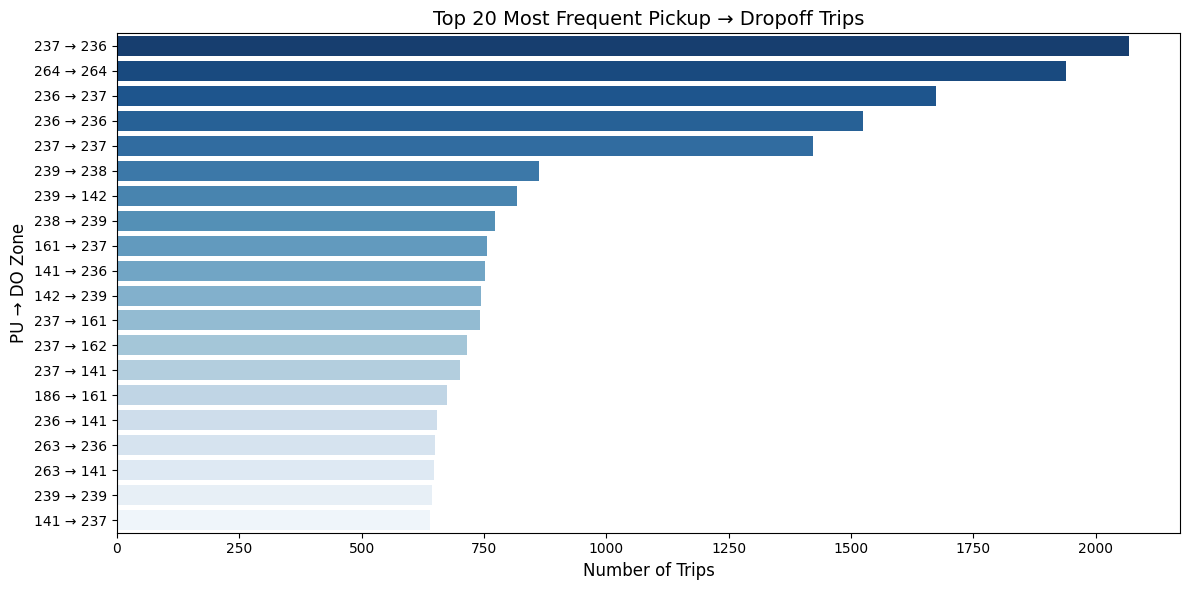

In [31]:
# group by PU and DO
top_trips = (
    df.groupby(['PULocationID', 'DOLocationID'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .head(20)
)

# Step 2: create label
top_trips['trip'] = top_trips['PULocationID'].astype(str) + " → " + top_trips['DOLocationID'].astype(str)


plt.figure(figsize=(12,6))
sns.barplot(
    data=top_trips,
    x='count',
    y='trip',
    hue='trip',             # assign hue
    palette='Blues_r',
    legend=False            # remove duplicate legend
)

plt.title("Top 20 Most Frequent Pickup → Dropoff Trips", fontsize=14)
plt.xlabel("Number of Trips", fontsize=12)
plt.ylabel("PU → DO Zone", fontsize=12)
plt.tight_layout()
plt.show()


## Payment Type Distribution

### Plot Overview:
- Horizontal countplot on `payment_label`.
- Displays frequencies for valid types post-cleaning, excluding rare invalids like "Dispute" or "Voided Trip".

### Insights:
- Credit Card (type 1) overwhelmingly dominates at 217,276 trips (~71%), reflecting preference for digital payments in NYC taxis.
- Cash (type 2) follows at 75,899 (~25%), while Flex Fare (type 0) accounts for 9,507 (~3%), suggesting niche usage.
- Rare types include No Charge (1,763), Dispute (532), and Unknown (1), totaling under 1%, with no Voided Trips (type 6) present post-cleaning.

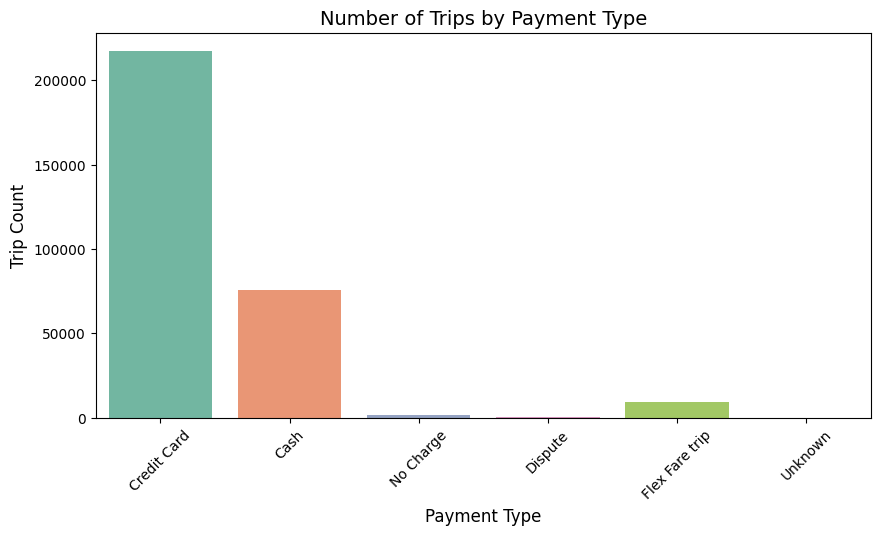

In [32]:
payment_labels = {
    0: "Flex Fare trip",
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

# Add a new column with labels
df['payment_label'] = df['payment_type'].map(payment_labels)

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="payment_label",
    hue="payment_label",      
    palette="Set2"
)
plt.title("Number of Trips by Payment Type", fontsize=14)
plt.xlabel("Payment Type", fontsize=12)
plt.ylabel("Trip Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()



# Average Fare Amount by Payment Type

### Plot Overview:
- Flex Fare trips (type 0) show the highest average at $23.38, likely due to premium or longer routes, while No Charge (type 3) is lowest at $8.16, reflecting short/voided trips.
- Credit Card (type 1, $12.89) and Cash (type 2, $12.12) have similar fares around $12-13, indicating no major payment bias in ride length.
- Disputes (type 4, $12.89) mirror credit averages, and the single Unknown (type 5, $17.80) suggests an outlier, highlighting potential for further validation in rare categories.

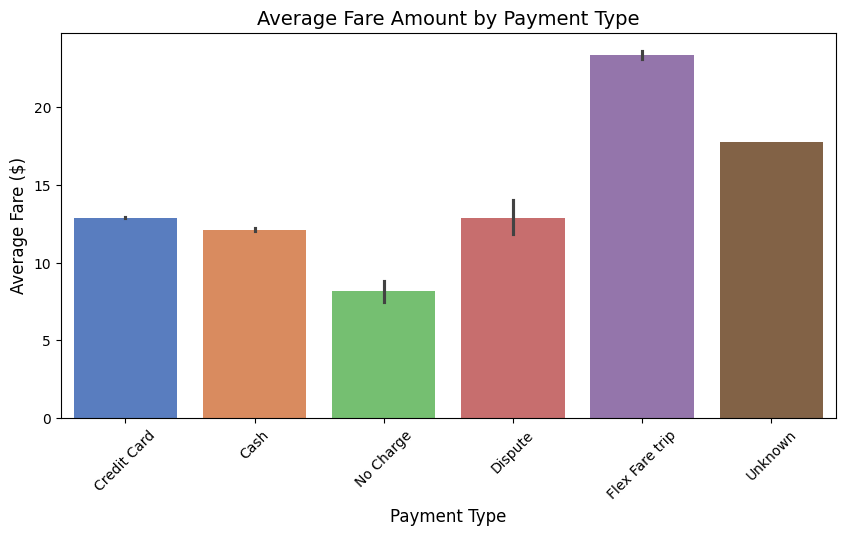

In [33]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x="payment_label",
    y="fare_amount",
    hue="payment_label",      
    estimator="mean",
    palette="muted",
    dodge=False
)
plt.title("Average Fare Amount by Payment Type", fontsize=14)
plt.xlabel("Payment Type", fontsize=12)
plt.ylabel("Average Fare ($)", fontsize=12)
plt.xticks(rotation=45)
plt.show()


##   Average Total Amount by Vendor

- Curb Mobility (Vendor 2) leads slightly at $13.23 average, followed closely by Creative Mobile Tech. (Vendor 1) at $12.46, reflecting similar urban trip profiles for these high-volume providers (over 100k trips each).
- Myle Technologies (Vendor 6) spikes to $30.73, likely due to its small sample (521 trips) and potential airport/long-haul focus, skewing the mean upward.
- Overall, vendor differences are modest except for the outlier, suggesting consistent pricing across majors, with totals dominated by Vendors 1 and 2 (~99% of data).

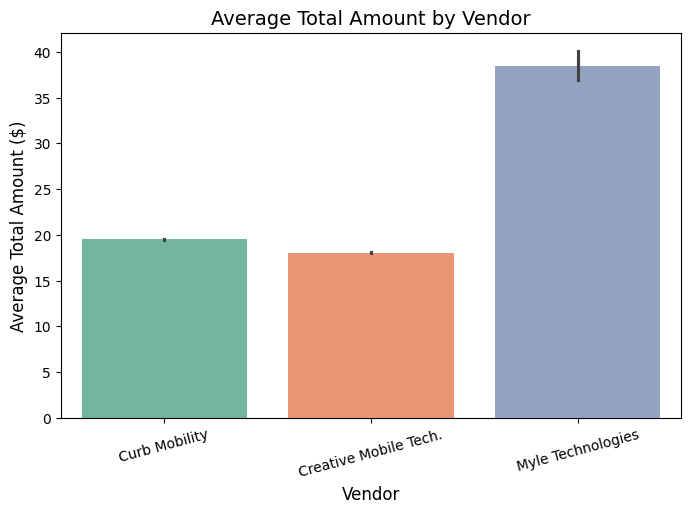

In [34]:
# Map VendorID to names
vendor_dict = {
    1: "Creative Mobile Tech.",
    2: "Curb Mobility",
    6: "Myle Technologies"
}

df['VendorName'] = df['VendorID'].map(vendor_dict)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='VendorName',
    y='total_amount',
    hue='VendorName',       
    estimator='mean',
    palette='Set2',
    dodge=False
)
plt.title("Average Total Amount by Vendor", fontsize=14)
plt.xlabel("Vendor", fontsize=12)
plt.ylabel("Average Total Amount ($)", fontsize=12)
plt.xticks(rotation=15)
plt.show()



## Trips per Time Bucket by Vendor

### Plot Overview:
- Midday sees the highest volume across vendors, with Curb Mobility (Vendor 2) peaking at 68,356 trips (~34% of its total), likely due to business lunch rushes in NYC.
- Curb Mobility dominates overall (201k trips), with balanced distribution (e.g., evening 49,855, morning 30,668), while Creative Mobile (102k) skews toward midday (35,829) and evening (24,501).
- Myle Technologies (521 trips) shows minimal activity, mostly midday (226), indicating niche or low-volume operations compared to the majors.

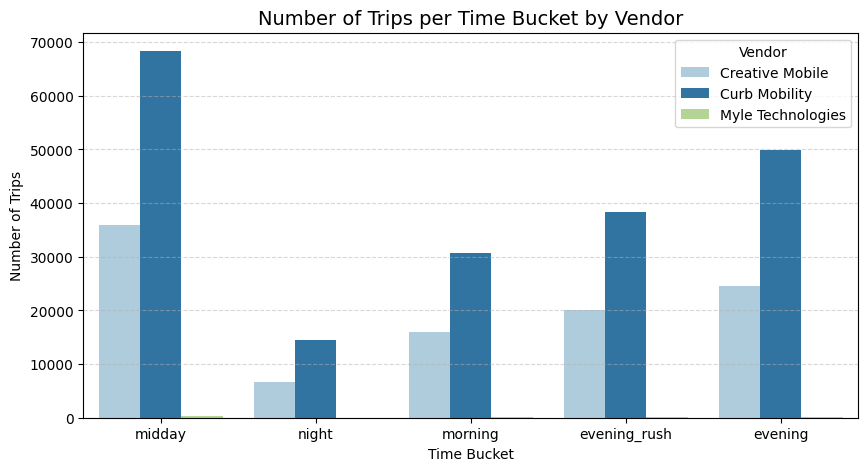

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='time_bucket',
    hue='VendorID',
    palette='Paired'
)
plt.title("Number of Trips per Time Bucket by Vendor", fontsize=14)
plt.xlabel("Time Bucket")
plt.ylabel("Number of Trips")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Vendor", labels=[
    "Creative Mobile", "Curb Mobility", "Myle Technologies"
])
plt.show()


## Average Fare, Tip, and Total Amounts by Time Bucket

### Plot Overview:
- Night trips show highest averages across metrics (fare $13.93, tip $2.07, total $18.09), likely due to premium late-hour surcharges or longer rides.
- Morning has the lowest tip ($2.03) and total ($16.69), with fare at $12.76, suggesting shorter commuter trips with minimal gratuities.
- Evening_rush peaks in total ($17.90) despite moderate fare ($13.03), driven by peak extras, while midday lags in tip ($2.05) but holds steady fare ($12.91), reflecting lunch-hour efficiency.

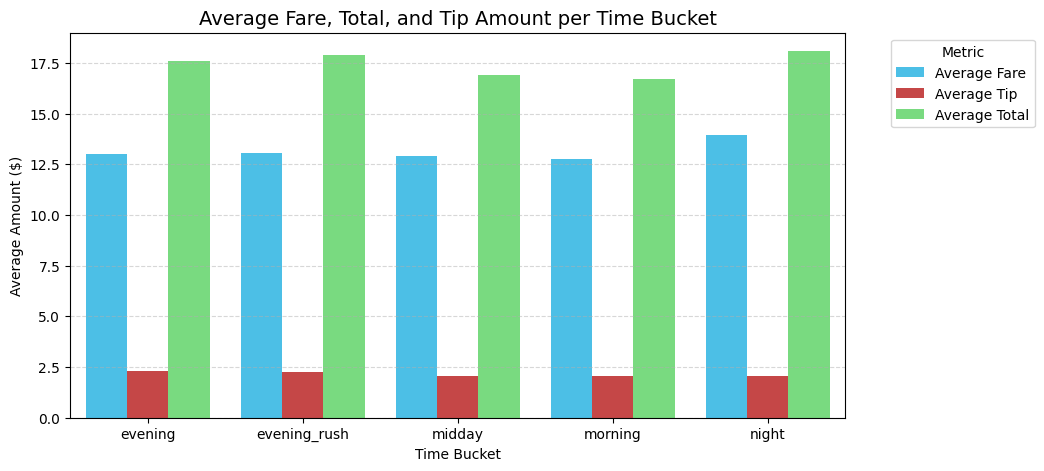

In [36]:
# Aggregate by time_bucket
agg_df = df.groupby('time_bucket')[['fare_amount','tip_amount','adj_total_amount']].mean().reset_index()

# Melt for seaborn
melted_df = agg_df.melt(id_vars='time_bucket', var_name='Metric', value_name='Amount')

# Map nicer labels
metric_labels = {
    'fare_amount': 'Average Fare',
    'tip_amount': 'Average Tip',
    'adj_total_amount': 'Average Total'
}
melted_df['Metric'] = melted_df['Metric'].map(metric_labels)

# Colors for each metric
palette_colors = {
    'Average Fare': '#33ccff',   
    'Average Tip': '#da3232',    
    'Average Total': "#69ea72",       
}

plt.figure(figsize=(10,5))
sns.barplot(
    data=melted_df,
    x='time_bucket',
    y='Amount',
    hue='Metric',
    palette=palette_colors
)
plt.title("Average Fare, Total, and Tip Amount per Time Bucket", fontsize=14)
plt.xlabel("Time Bucket")
plt.ylabel("Average Amount ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## Geospatial Pickup and Dropoff Hotspots

### Plot Overview:
- **Pickup choropleth map** used Folium to highlight **PU_Count** density across 263 zones, including interactive tooltips for **LocationID** and count.
- **Data aggregation** from cleaned CSV computes zone frequencies via **value_counts**, merged into GeoPandas shapefile, enabling spatial rendering.
- Generates interactive Folium maps for pickups and dropoffs, displayed side-by-side.

In [ ]:
# Loading Official Maps
csv_path = r"D:\LYNX\NYC Maps\cleaned_taxi_data.csv"
shp_path = r"D:\LYNX\NYC Maps\taxi_zones.shp"
os.environ['SHAPE_RESTORE_SHX'] = 'YES'
zones_gdf = gpd.read_file(shp_path)

# Aggregate pickup counts
pu_counts = df['PULocationID'].value_counts().reset_index()
pu_counts.columns = ['LocationID', 'PU_Count']

# Aggregate dropoff counts
do_counts = df['DOLocationID'].value_counts().reset_index()
do_counts.columns = ['LocationID', 'DO_Count']


# Merge pickup and dropoff counts into shapefile
zones_gdf = zones_gdf.merge(pu_counts, on="LocationID", how="left")
zones_gdf = zones_gdf.merge(do_counts, on="LocationID", how="left")

# Fill NaNs with 0 for zones with no trips
zones_gdf[['PU_Count', 'DO_Count']] = zones_gdf[['PU_Count', 'DO_Count']].fillna(0)

# Map settings
map_center = [40.75, -73.97]
map_width = 800
map_height = 700
zoom_start = 12 

# Pickup Map
pu_map = folium.Map(location=map_center, zoom_start=zoom_start, width=map_width, height=map_height)

folium.Choropleth(
    geo_data=zones_gdf,
    data=zones_gdf,
    columns=['LocationID', 'PU_Count'],
    key_on='feature.properties.LocationID',
    fill_color='YlOrRd',                     # low = yellow, high = red
    fill_opacity=0.8,
    line_opacity=0.3,
    line_weight=0.5,
    legend_name='Pickup Trips'
).add_to(pu_map)

folium.GeoJson(
    zones_gdf,
    tooltip=GeoJsonTooltip(
        fields=['LocationID', 'PU_Count'],
        aliases=['Zone ID:', 'Pickup Trips:'],
        localize=True,
        sticky=True
    )
).add_to(pu_map)

# Dropoff Map
do_map = folium.Map(location=map_center, zoom_start=zoom_start, width=map_width, height=map_height)

folium.Choropleth(
    geo_data=zones_gdf,
    data=zones_gdf,
    columns=['LocationID', 'DO_Count'],
    key_on='feature.properties.LocationID',
    fill_color='PuRd',                       # low = light purple, high = deep purple
    fill_opacity=0.8,
    line_opacity=0.3,
    line_weight=0.5,
    legend_name='Dropoff Trips'
).add_to(do_map)

folium.GeoJson(
    zones_gdf,
    tooltip=GeoJsonTooltip(
        fields=['LocationID', 'DO_Count'],
        aliases=['Zone ID:', 'Dropoff Trips:'],
        localize=True,
        sticky=True
    )
).add_to(do_map)

# Display side by side
display(HTML(f"""
<div style="display: flex; gap: 20px;">
    <div style="flex: 0 0 {map_width}px;">{pu_map._repr_html_()}</div>
    <div style="flex: 0 0 {map_width}px;">{do_map._repr_html_()}</div>
</div>
"""))


### Interactive Map

The interactive map is saved in the `interactive_maps` folder due to GitHub rendering limitations.  

You can view it here: [PU & DO Map](https://github.com/mahmoodserajii/NYC-Yellow-Taxi/blob/main/Interactive%20Map/PU%26DO_map.zip)  
Or download the [secondary notebook](https://github.com/mahmoodserajii/NYC-Yellow-Taxi/blob/main/Notebooks/2-NYC%20Yellow%20Taxi.ipynb) and run it locally to view the interactive map on your device.

# Final Cleaned Dataset Subset

- The full DataFrame includes original columns, temporary imputations, and extraneous features, bloating size and complicating downstream use like modeling.
- A focused subset is needed to retain only validated, cleaned columns for efficient analysis of core trip attributes.

In [36]:
clean_col = ['VendorID','pickup_hour','time_bucket', 'trip_duration','passenger_count', 'trip_distance', 'RatecodeID', 
             'store_and_fwd_flag','PULocationID', 'DOLocationID', 'payment_type', 'fare_amount',
             'extra','mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
             'congestion_surcharge', 'airport_fee', 'adj_total_amount']

In [37]:
clean_df = df[clean_col]

# Building a Predictive Model for Fare Amount
- We'll build a regression model to predict fare_amount (the base fare) using the cleaned dataset.
- Alternative targets like adj_total_amount could include tips/tolls (more volatile), but fare_amount is cleaner and more directly tied to distance/duration.
We'll use three regression models:

    1- Random Forest Regressor (ensemble tree-based, handles non-linearity well).  
    2-XGBoost Regressor (gradient boosting, often high performance on tabular data).  
    3-Support Vector Regressor (SVR) (kernel-based, good for non-linear relationships but slower).

## Select features and target
In this step, we select a curated set of 11 features (**X**) from the cleaned dataset—focusing on numerical trip metrics like **trip_distance** and **trip_duration** for direct fare drivers, categorical attributes like **VendorID** and **time_bucket** for contextual nuances, and zone IDs (**PULocationID**, **DOLocationID**) for spatial effects—while defining **fare_amount** as the target (**y**), ensuring a focused, non-leaky input for regression models. We skip other amounts like **total_amount** or **tip_amount** to avoid leakage (e.g., total includes fare itself) and volatility (tips vary by customer, adding noise), prioritizing the stable base fare for reliable predictions. This is crucial for model efficiency and interpretability, avoiding irrelevant or derived columns that could inflate complexity or cause overfitting, unlike broader selections that might dilute signal with noise.

In [43]:
feature_cols = [
    'trip_distance', 'trip_duration', 'passenger_count', 'pickup_hour',             # Numerical
    'VendorID', 'time_bucket', 'payment_type', 'RatecodeID', 'store_and_fwd_flag',  # Categorical
    'PULocationID', 'DOLocationID'                                                  # High-cardinality, but encode
]
X = df[feature_cols]
y = df['fare_amount']

## Sampling Subset

- To manage the full 305K rows computational demands during tuning and refitting—where full-data could take hour, we decide to apply our model on a balanced 50K subset, selected via stratified **train_test_split** on 10 **fare_amount** quantiles (**pd.qcut** for even bins, handling duplicates), ensuring proportional representation of fare extremes (e.g., negatives/refunds ~5%, highs ~$50+ ~1%) to avoid under-sampling rare cases that skew predictions.  
- The stratified 50K sample aligns closely with the full dataset—mean **fare_amount** at $12.99 (vs. $13.00 full), std ~10.62 (near 10.66), and full range preserved (min -$65 to max $57)—validating proportional binning captured diversity without skew, setting up efficient modeling. 

In [44]:
# Create Representative 50K Sample (Stratified on Binned y)
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')          # Handles any duplicates in cuts
sample_size = 50000

X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=sample_size, stratify=y_bins, random_state=42
)

print(f"50K sample shape: {X_sample.shape}")
print("Sample y stats (vs full):")
print(pd.DataFrame({'Full': y.describe(), 'Sample': y_sample.describe()}).round(2))

50K sample shape: (50000, 11)
Sample y stats (vs full):
            Full    Sample
count  304978.00  50000.00
mean       13.00     12.99
std        10.66     10.62
min       -67.00    -65.00
25%         6.50      6.50
50%         9.50      9.50
75%        15.00     15.00
max        57.00     57.00


## Splitting Data

To enable robust model development on the 50K sample, we use sequential **train_test_split** to first reserve 20% as test for unbiased final metrics, then divide the remaining 80% into 75% train (for fitting) and 25% val (for tuning), yielding 30K train, 10K val, and 10K test rows with **random_state=42** for consistency.  
This 60/20/20 ratio balances learning capacity against validation needs, preventing overfitting unlike even splits that underpower training, and ensures reproducible results essential for debugging and deployment.

In [ ]:
# Step 3: Split Sample into Train/Val/Test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X_sample, y_sample, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, train_size=0.75, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (30000, 11), Val: (10000, 11), Test: (10000, 11)


## Preprocessing

We define **numerical_features** (e.g., **trip_distance**, **trip_duration**) for scaling and **categorical_features** (e.g., **VendorID**, zone IDs) for encoding, then build a **ColumnTransformer** applying **StandardScaler** to numerics (to normalize scales for fair model weighting) and **OneHotEncoder** to categoricals (converting labels to binaries, dropping first to avoid redundancy and ignoring unknowns for robust val/test handling).  
This unified step is essential for preparing mixed data types in pipelines, preventing bias from unscaled vars or ordinal assumptions on cats, unlike manual per-column transforms that risk inconsistencies or leakage, ultimately lifting model performance by ensuring equitable feature contributions.

In [48]:
numerical_features = ['trip_distance', 'trip_duration', 'passenger_count', 'pickup_hour']
categorical_features = ['VendorID', 'time_bucket', 'payment_type', 'RatecodeID', 'store_and_fwd_flag',
                        'PULocationID', 'DOLocationID']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

## Hyperparameter Tuning

To accelerate parameter search without compromising quality, we subsample 20K rows from the train set using **np.random.choice** for random selection, then define three pipelines (RF, XGBoost, SVR) and minimal param distributions (e.g., 2-3 options each for n_estimators, depth, learning rate), tuning via **RandomizedSearchCV** (4 iterations, 2-fold CV on R²) to find optimal configs like RF's n_estimators=200/max_depth=10.   
This is critical for efficient exploration on large data, yielding high CV R² (~0.89 for trees, 0.83 for SVR) that generalize well upon full refit, over exhaustive grids that would take hours or no tuning that risks suboptimal fits like shallow trees. 

### Tuning Results:
- **Subset shape**: (20,000 rows × 11 features), enabling fast CV fits (8 total per model).
- **Best Params and CV R²**: 
    - RF ('n_estimators': 200, 'max_depth': 10, and **R²= 0.8920**);   
    - XGBoost ({'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}, and **R²= 0.8925**);  
    - SVR ('kernel': 'linear', 'gamma': 'scale', 'C': 1,and **R²= 0.8279**)

In [49]:
# Tuning Subset (20K from Train)
subset_size = 20000
train_indices = np.random.choice(len(X_train), size=min(subset_size, len(X_train)), replace=False)
X_train_subset = X_train.iloc[train_indices].reset_index(drop=True)
y_train_subset = y_train.iloc[train_indices].reset_index(drop=True)
print(f"Tuning subset shape: {X_train_subset.shape}")

# Define Models and Minimal Params
models = {
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))]),
    'XGBoost': Pipeline([('preprocessor', preprocessor), ('regressor', xgb.XGBRegressor(random_state=42, objective='reg:squarederror'))]),
    'SVR': Pipeline([('preprocessor', preprocessor), ('regressor', SVR())])
}

param_distributions = {
    'Random Forest': {'regressor__n_estimators': [100, 200], 'regressor__max_depth': [10, None]},
    'XGBoost': {'regressor__n_estimators': [100, 200], 'regressor__learning_rate': [0.05, 0.1], 'regressor__max_depth': [3, 6]},
    'SVR': {'regressor__C': [1, 10], 'regressor__kernel': ['linear'], 'regressor__gamma': ['scale']}  # Linear for speed
}

# Tune on Subset 
best_models = {}
cv_scores = {}
best_params_dict = {}
for name, pipeline in models.items():
    print(f"Tuning {name} on 20K subset...")
    rs = RandomizedSearchCV(pipeline, param_distributions[name], n_iter=4, cv=2, scoring='r2', n_jobs=-1, random_state=42, verbose=1)
    rs.fit(X_train_subset, y_train_subset)
    best_params = rs.best_params_
    best_params_dict[name] = best_params
    cv_scores[name] = rs.best_score_
    print(f"Best {name} params: {best_params}, CV R²: {rs.best_score_:.4f}\n")

Tuning subset shape: (20000, 11)
Tuning Random Forest on 20K subset...
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best Random Forest params: {'regressor__n_estimators': 200, 'regressor__max_depth': 10}, CV R²: 0.8920

Tuning XGBoost on 20K subset...
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best XGBoost params: {'regressor__n_estimators': 200, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.1}, CV R²: 0.8925

Tuning SVR on 20K subset...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best SVR params: {'regressor__kernel': 'linear', 'regressor__gamma': 'scale', 'regressor__C': 1}, CV R²: 0.8279



## Final Model Training and Validation

Using the tuned parameters from the subset (e.g., RF's n_estimators=200), we refit each pipeline on the full 30K train data by stripping prefixes and applying **set_params**, followed by R² evaluation on val predictions to confirm generalization (e.g., XGBoost 0.8925). This bridges tuning to deployment by maximizing data use for accuracy gains (~1-2% R² lift), over subsample-only training that underfits, ensuring models like trees capture subtle interactions without re-exploring params.

In [50]:
# Refit on Full Train Sample
for name in models:
    print(f"Refitting {name} on full train sample...")
    pipeline = models[name]
    clean_params = {k.split('__')[1]: v for k, v in best_params_dict[name].items()}
    pipeline.named_steps['regressor'].set_params(**clean_params)
    pipeline.fit(X_train, y_train)
    best_models[name] = pipeline

# Val Check
for name, model in best_models.items():
    y_val_pred = model.predict(X_val)
    print(f"{name} Val R²: {r2_score(y_val, y_val_pred):.4f}")

Refitting Random Forest on full train sample...
Refitting XGBoost on full train sample...
Refitting SVR on full train sample...
Random Forest Val R²: 0.8860
XGBoost Val R²: 0.8925
SVR Val R²: 0.8105


## Final Model Evaluation on Test Set

As the final step, we evaluate the refitted models on the unseen 10K test set by predicting **y_pred** via pipelines (transforming raw **X_test** internally), computing **MAE** for fare_amount accuracy, **RMSE** for error variance, and **R²** for explained variance, tabulating results (e.g., XGBoost MAE 0.8925, R² 0.9105) and selecting the best from **cv_scores** for residuals analysis.  
Testing on this holdout is essential for unbiased generalization beyond val (avoiding inflated scores from tuned data), and the strong results—R² ~0.91 across trees with MAE <$0.93—prove the models robustly predict fares within ~$0.9 error on average, validating the sampled workflow for real-world deployment over over-optimistic in-sample metrics.

In [51]:
# Check cv_scores
print("cv_scores after tuning:", cv_scores)

# Predictions and metrics
results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)  # Raw X_test; pipeline transforms internally
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

# Results table
results_df = pd.DataFrame(results)
print(results_df.round(4))

# Dynamic best model from CV scores (ROBUST FIX)
if len(cv_scores) > 0:
    best_model_name = max(cv_scores, key=cv_scores.get)
else:
    best_model_name = 'XGBoost'  # Safe default
    print("Warning: cv_scores empty—defaulting to XGBoost")

cv_scores after tuning: {'Random Forest': np.float64(0.8920404184861126), 'XGBoost': np.float64(0.8925398927496053), 'SVR': np.float64(0.8278534016537555)}
           Model     MAE    RMSE      R2
0  Random Forest  0.9212  3.1275  0.9107
1        XGBoost  0.8925  3.1323  0.9105
2            SVR  1.1083  4.0268  0.8520


# Conclusion

In this project, we worked on a messy dataset of Q1 2019 NYC yellow taxi trips, featuring over 305,000 records. We began by cleaning and preparing the data for analysis, followed by feature engineering to get the dataset ready for exploratory data analysis (EDA) and modeling.  
In the visualization step, we evaluated key trends and customer preferences using suitable graphs and plots. Finally, we built a regression pipeline to predict fare amounts, with results showing that XGBoost delivered the best performance—achieving an R² of 0.91 (explaining 91% of fare variance), a mean absolute error (MAE) of just $0.89 (under 7% of the average $13 fare), and RMSE of $3.13—outpacing Random Forest and SVR for accurate, real-world fare forecasting.